In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn
import lightgbm as lgb
import shap

print(f"🐍 Python      : {sys.version}")
print(f"📦 pandas      : {pd.__version__}")
print(f"📦 numpy       : {np.__version__}")
print(f"📦 scikit-learn: {sklearn.__version__}")
print(f"📦 lightgbm    : {lgb.__version__}")
print(f"📦 shap        : {shap.__version__}")
print(f"\n📂 Python path: {sys.executable}")

c:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🐍 Python      : 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
📦 pandas      : 2.2.1
📦 numpy       : 1.26.4
📦 scikit-learn: 1.4.1.post1
📦 lightgbm    : 4.3.0
📦 shap        : 0.45.0

📂 Python path: c:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\.venv\Scripts\python.exe


In [1]:
# Cell 0 — Imports + Project Paths
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, recall_score,
    precision_score, confusion_matrix, classification_report, roc_curve
)
import lightgbm as lgb
import shap

# ===== Config =====
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")
RANDOM_STATE = 42

# ===== Paths =====
ROOT = Path("..").resolve()      # notebook/ → กลับไป root
DATA_DIR = ROOT / "data"
REPORT_DIR = ROOT / "report"
FIG_DIR = REPORT_DIR / "figures"
MODEL_DIR = REPORT_DIR / "models"
RESULT_DIR = REPORT_DIR / "results"

for d in [FIG_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"📂 Project root  : {ROOT}")
print(f"📂 Data dir      : {DATA_DIR}")

# Verify
for f in ["cs-training.csv", "cs-test.csv"]:
    path = DATA_DIR / f
    status = "✅" if path.exists() else "❌"
    print(f"   {status} {f}")

c:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📂 Project root  : C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk
📂 Data dir      : C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\data
   ✅ cs-training.csv
   ✅ cs-test.csv


🏦 Loan Default Prediction — Credit Risk Modeling  

Author: Kantinan Sukpongtarin | Risk Officer, BAAC  
Dataset: Give Me Some Credit (Kaggle)  
Environment: Python 3.11.9 | VS Code Jupyter

🎯 Objective
พัฒนา ML model ทำนายความน่าจะเป็นที่ลูกค้าจะเกิด **90-day delinquency** ภายใน 2 ปี  
โดยเปรียบเทียบ 3 algorithms: Logistic+Lasso, Random Forest, LightGBM

In [2]:
# Cell 0 — Setup + Project Paths
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

# === ML / Stats ===
from sklearn.model_selection import (
    StratifiedKFold, train_test_split, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, recall_score,
    precision_score, confusion_matrix, classification_report, roc_curve
)
import lightgbm as lgb
import shap

# ===== Global config =====
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

# ===== Project paths =====
# notebook อยู่ใน notebook/ → ต้อง ".." กลับไป root ของ project
ROOT = Path("..").resolve()

DATA_DIR   = ROOT / "data"
REPORT_DIR = ROOT / "report"
FIG_DIR    = REPORT_DIR / "figures"
MODEL_DIR  = REPORT_DIR / "models"
RESULT_DIR = REPORT_DIR / "results"

# สร้าง output folders (ถ้ายังไม่มี)
for d in [FIG_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ===== Verify setup =====
print("=" * 60)
print("📂 Project Structure")
print("=" * 60)
print(f"ROOT      : {ROOT}")
print(f"DATA_DIR  : {DATA_DIR}")
print(f"REPORT_DIR: {REPORT_DIR}")

print("\n📋 Required data files:")
for f in ["cs-training.csv", "cs-test.csv", "Data Dictionary.xls", "sampleEntry.csv"]:
    path = DATA_DIR / f
    status = "✅" if path.exists() else "❌"
    size = f"({path.stat().st_size:,} bytes)" if path.exists() else ""
    print(f"   {status} {f:25s} {size}")

print("\n📦 Output folders:")
for d in [FIG_DIR, MODEL_DIR, RESULT_DIR]:
    print(f"   📁 {d.relative_to(ROOT)}")

print("\n✅ Setup complete! Random state =", RANDOM_STATE)

📂 Project Structure
ROOT      : C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk
DATA_DIR  : C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\data
REPORT_DIR: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report

📋 Required data files:
   ✅ cs-training.csv           (7,564,965 bytes)
   ✅ cs-test.csv               (4,983,329 bytes)
   ✅ Data Dictionary.xls       (14,848 bytes)
   ✅ sampleEntry.csv           (1,907,226 bytes)

📦 Output folders:
   📁 report\figures
   📁 report\models
   📁 report\results

✅ Setup complete! Random state = 42


Cell 1 — Load Dataset

📊 Dataset: Give Me Some Credit (Kaggle)
# 
**`cs-training.csv`** — มี target (`SeriousDlqin2yrs`) → ใช้สำหรับ train + validate

**`Data Dictionary.xls`** — คำอธิบาย feature

In [3]:
# Cell 1 — Load training data
df_raw = pd.read_csv(DATA_DIR / "cs-training.csv", index_col=0)

print(f"📊 Raw shape: {df_raw.shape}")
print(f"   • Rows    : {df_raw.shape[0]:,}")
print(f"   • Columns : {df_raw.shape[1]}")
print(f"\n💾 Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Preview
df_raw.head()

📊 Raw shape: (150000, 11)
   • Rows    : 150,000
   • Columns : 11

💾 Memory usage: 13.73 MB


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
# อ่าน Data Dictionary
try:
    data_dict = pd.read_excel(DATA_DIR / "Data Dictionary.xls")
    print("📖 Feature descriptions:\n")
    # แสดงเฉพาะ column สำคัญ
    for col in data_dict.columns:
        print(f"   • {col}")
    print()
    display(data_dict)
except ImportError:
    print("⚠️ ต้องติดตั้ง xlrd ก่อน:")
    print("   pip install xlrd")
except Exception as e:
    print(f"⚠️ Could not read Data Dictionary: {e}")

📖 Feature descriptions:

   • Unnamed: 0
   • Unnamed: 1
   • Unnamed: 2



,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Variable Name,Description,Type
1,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
2,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
3,age,Age of borrower in years,integer
4,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
5,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
6,MonthlyIncome,Monthly income,real
7,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
8,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
9,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer


 🎯 Quick Target Check

In [ ]:
# Cell 1 — Load + Smart Imbalance Detection
df_raw = pd.read_csv(DATA_DIR / "cs-training.csv", index_col=0)

print(f"📊 Raw shape: {df_raw.shape}")
print(f"💾 Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

target_col = "SeriousDlqin2yrs"

# ===== 1) คำนวณ class statistics =====
target_counts = df_raw[target_col].value_counts().sort_index()
target_pct    = df_raw[target_col].value_counts(normalize=True).sort_index() * 100
n_classes     = df_raw[target_col].nunique()
minority_pct  = target_pct.min()ิ
majority_pct  = target_pct.max()
imb_ratio     = majority_pct / minority_pct

# ===== 2) จำแนกระดับ imbalance =====
def classify_imbalance(minority_pct):
    """แบ่งระดับ imbalance ตามมาตรฐานวิชาการ (He & Garcia, 2009)"""
    if minority_pct >= 40:
        return "balanced",         "🟢 Balanced"
    elif minority_pct >= 20:
        return "mild_imbalance",   "🟡 Mild imbalance"
    elif minority_pct >= 5:
        return "moderate_imbalance", "🟠 Moderate imbalance"
    elif minority_pct >= 1:
        return "severe_imbalance", "🔴 Severe imbalance"
    else:
        return "extreme_imbalance", "🚨 Extreme imbalance"

level, label = classify_imbalance(minority_pct)

# ===== 3) แสดงผล =====
print("=" * 60)
print(f"🎯 Target: {target_col}")
print("=" * 60)

summary = pd.DataFrame({
    "count": target_counts,
    "pct (%)": target_pct.round(2),
})
print(summary)

print(f"\n📊 Imbalance Analysis:")
print(f"   • Classes        : {n_classes}")
print(f"   • Minority class : {minority_pct:.2f}%")
print(f"   • Majority class : {majority_pct:.2f}%")
print(f"   • Ratio          : 1 : {imb_ratio:.1f}")
print(f"   • Level          : {label}")

📊 Raw shape: (150000, 11)
💾 Memory usage: 13.73 MB

🎯 Target: SeriousDlqin2yrs
                   count  pct (%)
SeriousDlqin2yrs                 
0                 139974    93.32
1                  10026     6.68

📊 Imbalance Analysis:
   • Classes        : 2
   • Minority class : 6.68%
   • Majority class : 93.32%
   • Ratio          : 1 : 14.0
   • Level          : 🟠 Moderate imbalance


In [8]:
# ===== 4) แนะนำ technique ตาม level =====
strategies = {
    "balanced": {
        "metrics":     ["Accuracy", "F1-score", "ROC-AUC"],
        "techniques":  ["No special handling needed"],
        "model_params": "default settings ใช้ได้เลย",
        "note":        "✅ ไม่ต้องทำอะไรพิเศษ"
    },
    "mild_imbalance": {
        "metrics":     ["F1-score", "ROC-AUC", "Balanced Accuracy"],
        "techniques":  ["class_weight='balanced'"],
        "model_params": "เพิ่ม class_weight='balanced' ใน sklearn",
        "note":        "⚖️ ใส่ class_weight ก็พอ"
    },
    "moderate_imbalance": {
        "metrics":     ["F1-score", "ROC-AUC", "PR-AUC", "Recall"],
        "techniques":  ["class_weight='balanced'", "scale_pos_weight (XGB/LGB)",
                        "SMOTE / ADASYN (oversampling)", "Random Undersampling"],
        "model_params": "class_weight + scale_pos_weight + resampling",
        "note":        "⚠️ ต้องใช้ technique เฉพาะ ห้ามใช้ Accuracy"
    },
    "severe_imbalance": {
        "metrics":     ["PR-AUC", "F1", "Recall", "KS statistic"],
        "techniques":  ["SMOTE + class_weight", "Cost-sensitive learning",
                        "Threshold tuning", "Ensemble (BalancedRandomForest)"],
        "model_params": "scale_pos_weight + SMOTE + custom threshold",
        "note":        "🚨 ต้องใช้หลาย technique ร่วมกัน + threshold tuning"
    },
    "extreme_imbalance": {
        "metrics":     ["PR-AUC", "Recall@Precision=k", "Top-k accuracy"],
        "techniques":  ["Anomaly detection (IsolationForest, AutoEncoder)",
                        "One-class SVM", "Heavy resampling", "Focal Loss"],
        "model_params": "ต้องคิดใหม่ว่าเป็น anomaly detection ไหม",
        "note":        "🆘 พิจารณา reframe เป็น anomaly detection แทน"
    },
}

s = strategies[level]

print("\n" + "=" * 60)
print(f"💡 Recommended Strategy: {label}")
print("=" * 60)

print(f"\n📈 ใช้ Metrics:")
for m in s["metrics"]:
    print(f"   • {m}")

print(f"\n🛠️ Techniques ที่แนะนำ:")
for t in s["techniques"]:
    print(f"   • {t}")

print(f"\n⚙️ Model parameters:")
print(f"   {s['model_params']}")

print(f"\n📝 Note: {s['note']}")


💡 Recommended Strategy: 🟠 Moderate imbalance

📈 ใช้ Metrics:
   • F1-score
   • ROC-AUC
   • PR-AUC
   • Recall

🛠️ Techniques ที่แนะนำ:
   • class_weight='balanced'
   • scale_pos_weight (XGB/LGB)
   • SMOTE / ADASYN (oversampling)
   • Random Undersampling

⚙️ Model parameters:
   class_weight + scale_pos_weight + resampling

📝 Note: ⚠️ ต้องใช้ technique เฉพาะ ห้ามใช้ Accuracy


In [10]:
# Cell 1c — Save Configuration
CONFIG = {
    "target_col":   target_col,
    "n_samples":    len(df_raw),
    "n_features":   df_raw.shape[1] - 1,
    "imbalance":    {
        "level":           level,
        "minority_pct":    round(minority_pct, 2),
        "imbalance_ratio": round(imb_ratio, 2),
        "scale_pos_weight": round(imb_ratio, 2),
    },
    "recommended_metrics": s["metrics"],
}

import json
print("=" * 60)
print("💾 CONFIG saved for downstream cells:")
print("=" * 60)
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))

💾 CONFIG saved for downstream cells:
{
  "target_col": "SeriousDlqin2yrs",
  "n_samples": 150000,
  "n_features": 10,
  "imbalance": {
    "level": "moderate_imbalance",
    "minority_pct": 6.68,
    "imbalance_ratio": 13.96,
    "scale_pos_weight": 13.96
  },
  "recommended_metrics": [
    "F1-score",
    "ROC-AUC",
    "PR-AUC",
    "Recall"
  ]
}


Cell 2 — Rename Columns + Schema Inspection

- Kaggle ใช้ชื่อ column ยาวมาก (`NumberOfTime30-59DaysPastDueNotWorse`)
- มี **dash (`-`)** ทำให้ใช้ใน Python ลำบาก (ต้อง `df["..."]` ตลอด)
- เปลี่ยนเป็น **snake_case** สั้นๆ → อ่านง่าย + เขียน code ลื่นกว่า
- แนบ **`COLUMN_MAP`** ไว้ดูที่มาเดิมได้ตลอด (audit trail)

In [11]:
# Cell 2 — Rename columns + Type inspection

# ===== 1) Mapping: Kaggle name → snake_case =====
COLUMN_MAP = {
    "SeriousDlqin2yrs":                       "default_2yr",        # TARGET
    "RevolvingUtilizationOfUnsecuredLines":   "rev_util",            # ใช้ credit ไปกี่ %
    "age":                                    "age",                 # อายุ
    "NumberOfTime30-59DaysPastDueNotWorse":   "past_due_30_59",      # ครั้งที่ค้าง 30-59 วัน
    "DebtRatio":                              "debt_ratio",          # หนี้สิน / รายได้
    "MonthlyIncome":                          "monthly_income",      # รายได้ต่อเดือน
    "NumberOfOpenCreditLinesAndLoans":        "n_credit_lines",      # จำนวน loan/บัตรเปิดอยู่
    "NumberOfTimes90DaysLate":                "past_due_90",         # ครั้งที่ค้าง ≥90 วัน
    "NumberRealEstateLoansOrLines":           "n_real_estate",       # loan อสังหา
    "NumberOfTime60-89DaysPastDueNotWorse":   "past_due_60_89",      # ครั้งที่ค้าง 60-89 วัน
    "NumberOfDependents":                     "n_dependents",        # จำนวนผู้พึ่งพิง
}

# ===== 2) Apply rename =====
df = df_raw.rename(columns=COLUMN_MAP).copy()

# ===== 3) Update CONFIG ให้ใช้ชื่อใหม่ =====
CONFIG["target_col"]   = "default_2yr"
CONFIG["feature_cols"] = [c for c in df.columns if c != CONFIG["target_col"]]
CONFIG["column_map"]   = COLUMN_MAP

# ===== 4) Schema overview =====
print("=" * 75)
print("📋 Schema Overview")
print("=" * 75)

schema = pd.DataFrame({
    "original_name": list(COLUMN_MAP.keys()),
    "new_name":      list(COLUMN_MAP.values()),
    "dtype":         [str(df[c].dtype) for c in COLUMN_MAP.values()],
    "n_unique":      [df[c].nunique() for c in COLUMN_MAP.values()],
    "n_missing":     [df[c].isnull().sum() for c in COLUMN_MAP.values()],
    "pct_missing":   [round(df[c].isnull().mean() * 100, 2) for c in COLUMN_MAP.values()],
})

# จัด format ให้สวย
print(schema.to_string(index=False))

📋 Schema Overview
                       original_name       new_name   dtype  n_unique  n_missing  pct_missing
                    SeriousDlqin2yrs    default_2yr   int64         2          0         0.00
RevolvingUtilizationOfUnsecuredLines       rev_util float64    125728          0         0.00
                                 age            age   int64        86          0         0.00
NumberOfTime30-59DaysPastDueNotWorse past_due_30_59   int64        16          0         0.00
                           DebtRatio     debt_ratio float64    114194          0         0.00
                       MonthlyIncome monthly_income float64     13594      29731        19.82
     NumberOfOpenCreditLinesAndLoans n_credit_lines   int64        58          0         0.00
             NumberOfTimes90DaysLate    past_due_90   int64        19          0         0.00
        NumberRealEstateLoansOrLines  n_real_estate   int64        28          0         0.00
NumberOfTime60-89DaysPastDueNotWorse past_

🔍 Type Categorization

จัดกลุ่ม feature ตามประเภท เพื่อ:
- รู้ว่าตัวไหนต้อง **scale** (continuous)
- รู้ว่าตัวไหนต้อง **bin/transform** (count-based)
- รู้ว่าตัวไหนต้อง **impute** (มี missing)

In [12]:
# ===== 5) Categorize features by semantic type =====
FEATURE_GROUPS = {
    "target":           ["default_2yr"],
    "demographic":      ["age", "n_dependents"],
    "financial":        ["monthly_income", "debt_ratio", "rev_util"],
    "credit_behavior":  ["n_credit_lines", "n_real_estate"],
    "delinquency":      ["past_due_30_59", "past_due_60_89", "past_due_90"],
}

# Update CONFIG
CONFIG["feature_groups"] = FEATURE_GROUPS

print("=" * 60)
print("🗂️  Feature Groups (จำแนกตามความหมายเชิงธุรกิจ)")
print("=" * 60)

for group, cols in FEATURE_GROUPS.items():
    icon = {
        "target":           "🎯",
        "demographic":      "👤",
        "financial":        "💰",
        "credit_behavior":  "💳",
        "delinquency":      "⚠️",
    }[group]
    print(f"\n{icon}  {group.upper()}:")
    for c in cols:
        print(f"    • {c}")

# Save updated config
print("\n" + "=" * 60)
print(f"✅ Renamed columns. df.shape = {df.shape}")
print(f"📊 Total features: {len(CONFIG['feature_cols'])}")
print("=" * 60)
df.head()

🗂️  Feature Groups (จำแนกตามความหมายเชิงธุรกิจ)

🎯  TARGET:
    • default_2yr

👤  DEMOGRAPHIC:
    • age
    • n_dependents

💰  FINANCIAL:
    • monthly_income
    • debt_ratio
    • rev_util

💳  CREDIT_BEHAVIOR:
    • n_credit_lines
    • n_real_estate

⚠️  DELINQUENCY:
    • past_due_30_59
    • past_due_60_89
    • past_due_90

✅ Renamed columns. df.shape = (150000, 11)
📊 Total features: 10


,default_2yr,rev_util,age,past_due_30_59,debt_ratio,monthly_income,n_credit_lines,past_due_90,n_real_estate,past_due_60_89,n_dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Cell 3 — Statistical Summary + Outlier Detection

🎯 จุดประสงค์
ก่อนเข้า modeling ต้องเข้าใจ **distribution** ของแต่ละ feature และหา **outliers** ที่อาจ:
- เป็น **data error** (ต้องลบ/แก้)
- เป็น **special code** (เช่น 96, 98 = "no data")
- เป็น **extreme value จริง** (ต้อง winsorize)

In [13]:
# Cell 3 — Descriptive statistics + outlier flags

# ===== 1) Full describe() =====
print("=" * 80)
print("📊 Statistical Summary")
print("=" * 80)

stats = df.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]).T
stats["range"] = stats["max"] - stats["min"]
stats["iqr"]   = stats["75%"] - stats["25%"]

# จัดทศนิยมให้สวย
display(stats.round(2))

📊 Statistical Summary


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max,range,iqr
default_2yr,150000.0,0.07,0.25,0.0,0.0,0.00,0.00,0.00,1.0,1.00,1.0,1.0,0.00
rev_util,150000.0,6.05,249.76,0.0,0.0,0.03,0.15,0.56,1.0,1.09,50708.0,50708.0,0.53
age,150000.0,52.30,14.77,0.0,24.0,41.00,52.00,63.00,78.0,87.00,109.0,109.0,22.00
past_due_30_59,150000.0,0.42,4.19,0.0,0.0,0.00,0.00,0.00,2.0,4.00,98.0,98.0,0.00
debt_ratio,150000.0,353.01,2037.82,0.0,0.0,0.18,0.37,0.87,2449.0,4979.04,329664.0,329664.0,0.69
monthly_income,120269.0,6670.22,14384.67,0.0,0.0,3400.00,5400.00,8249.00,14587.6,25000.00,3008750.0,3008750.0,4849.00
n_credit_lines,150000.0,8.45,5.15,0.0,0.0,5.00,8.00,11.00,18.0,24.00,58.0,58.0,6.00
past_due_90,150000.0,0.27,4.17,0.0,0.0,0.00,0.00,0.00,1.0,3.00,98.0,98.0,0.00
n_real_estate,150000.0,1.02,1.13,0.0,0.0,0.00,1.00,2.00,3.0,4.00,54.0,54.0,2.00
past_due_60_89,150000.0,0.24,4.16,0.0,0.0,0.00,0.00,0.00,1.0,2.00,98.0,98.0,0.00


🔍 Outlier Detection — IQR Rule

IQR Rule (Tukey): ค่าผิดปกติคือค่าที่อยู่นอกช่วง [Q1 - 1.5×IQR, Q3 + 1.5×IQR]

In [14]:
# ===== 2) Detect outliers ด้วย IQR rule =====
def detect_outliers_iqr(df, col):
    """หา outliers ตาม IQR rule + คำนวณ % ที่เป็น outlier"""
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return {
        "feature":     col,
        "Q1":          round(q1, 2),
        "Q3":          round(q3, 2),
        "IQR":         round(iqr, 2),
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "n_outliers":  len(outliers),
        "pct_outliers": round(len(outliers) / len(df) * 100, 2),
        "max_value":   df[col].max(),
        "min_value":   df[col].min(),
    }


# Run on numeric features (ไม่รวม target)
numeric_features = [c for c in CONFIG["feature_cols"] 
                    if df[c].dtype in ["int64", "float64"]]

outlier_report = pd.DataFrame([detect_outliers_iqr(df, c) for c in numeric_features])
outlier_report = outlier_report.sort_values("pct_outliers", ascending=False)

print("=" * 90)
print("🔍 Outlier Detection Report (IQR Method)")
print("=" * 90)
display(outlier_report)

🔍 Outlier Detection Report (IQR Method)


,feature,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers,max_value,min_value
3,debt_ratio,0.18,0.87,0.69,-0.86,1.91,31311,20.87,329664.0,0.0
2,past_due_30_59,0.00,0.00,0.00,0.00,0.00,23982,15.99,98.0,0.0
9,n_dependents,0.00,1.00,1.00,-1.50,2.50,13336,8.89,20.0,0.0
6,past_due_90,0.00,0.00,0.00,0.00,0.00,8338,5.56,98.0,0.0
8,past_due_60_89,0.00,0.00,0.00,0.00,0.00,7604,5.07,98.0,0.0
4,monthly_income,3400.00,8249.00,4849.00,-3873.50,15522.50,4879,3.25,3008750.0,0.0
5,n_credit_lines,5.00,11.00,6.00,-4.00,20.00,3980,2.65,58.0,0.0
7,n_real_estate,0.00,2.00,2.00,-3.00,5.00,793,0.53,54.0,0.0
0,rev_util,0.03,0.56,0.53,-0.76,1.35,763,0.51,50708.0,0.0
1,age,41.00,63.00,22.00,8.00,96.00,46,0.03,109.0,0.0


⚠️ Suspected Data Quality Issues
มา flag ค่าที่น่าสงสัยว่าเป็น **data error** หรือ **special code**

In [15]:
# ===== 3) Domain-specific checks =====
print("=" * 80)
print("🕵️  Domain Knowledge Checks")
print("=" * 80)

issues = []

# Check 1: rev_util ควรอยู่ในช่วง 0-1 (เป็น %)
high_util = (df["rev_util"] > 1).sum()
pct = round(high_util / len(df) * 100, 2)
issues.append({
    "check": "rev_util > 1.0",
    "issue": "ใช้ credit เกิน limit (ผิดความหมาย)",
    "count": high_util,
    "pct":   pct,
    "severity": "🔴 High" if pct > 1 else "🟡 Medium",
})

# Check 2: rev_util สูงมาก
extreme_util = (df["rev_util"] > 10).sum()
pct = round(extreme_util / len(df) * 100, 2)
issues.append({
    "check": "rev_util > 10",
    "issue": "ค่าผิดธรรมชาติของ utilization",
    "count": extreme_util,
    "pct":   pct,
    "severity": "🚨 Critical" if extreme_util > 0 else "✅ OK",
})

# Check 3: debt_ratio สูงผิดปกติ (ปกติ < 1)
high_debt = (df["debt_ratio"] > 1).sum()
pct = round(high_debt / len(df) * 100, 2)
issues.append({
    "check": "debt_ratio > 1.0",
    "issue": "หนี้สูงกว่ารายได้ (อาจถูก หรือ data error)",
    "count": high_debt,
    "pct":   pct,
    "severity": "🟡 Medium",
})

# Check 4: past_due มีค่า 96, 98 (Kaggle ระบุว่าเป็น special code)
for col in ["past_due_30_59", "past_due_60_89", "past_due_90"]:
    special = df[df[col].isin([96, 98])][col].count()
    pct = round(special / len(df) * 100, 2)
    issues.append({
        "check": f"{col} ∈ {{96, 98}}",
        "issue": "Special code (น่าจะแปลว่า 'no data')",
        "count": special,
        "pct":   pct,
        "severity": "🟠 Action needed" if special > 0 else "✅ OK",
    })

# Check 5: age ต่ำกว่า 18 หรือสูงเกิน 100
weird_age = ((df["age"] < 18) | (df["age"] > 100)).sum()
pct = round(weird_age / len(df) * 100, 2)
issues.append({
    "check": "age < 18 or > 100",
    "issue": "อายุผิดธรรมชาติ",
    "count": weird_age,
    "pct":   pct,
    "severity": "🚨 Critical" if weird_age > 0 else "✅ OK",
})

# Check 6: monthly_income = 0
zero_income = (df["monthly_income"] == 0).sum()
pct = round(zero_income / len(df) * 100, 2)
issues.append({
    "check": "monthly_income == 0",
    "issue": "รายได้ 0 บาท (ไม่มีงาน? หรือ data error?)",
    "count": zero_income,
    "pct":   pct,
    "severity": "🟡 Medium" if zero_income > 0 else "✅ OK",
})

issues_df = pd.DataFrame(issues)
display(issues_df)

# Save findings
CONFIG["dq_issues"] = issues
print(f"\n✅ พบ data quality issues ทั้งหมด: {len(issues)} เรื่อง")
print(f"💾 บันทึกใน CONFIG['dq_issues']")

🕵️  Domain Knowledge Checks


,check,issue,count,pct,severity
0,rev_util > 1.0,ใช้ credit เกิน limit (ผิดความหมาย),3321,2.21,🔴 High
1,rev_util > 10,ค่าผิดธรรมชาติของ utilization,241,0.16,🚨 Critical
2,debt_ratio > 1.0,หนี้สูงกว่ารายได้ (อาจถูก หรือ data error),35137,23.42,🟡 Medium
3,"past_due_30_59 ∈ {96, 98}",Special code (น่าจะแปลว่า 'no data'),269,0.18,🟠 Action needed
4,"past_due_60_89 ∈ {96, 98}",Special code (น่าจะแปลว่า 'no data'),269,0.18,🟠 Action needed
5,"past_due_90 ∈ {96, 98}",Special code (น่าจะแปลว่า 'no data'),269,0.18,🟠 Action needed
6,age < 18 or > 100,อายุผิดธรรมชาติ,14,0.01,🚨 Critical
7,monthly_income == 0,รายได้ 0 บาท (ไม่มีงาน? หรือ data error?),1634,1.09,🟡 Medium



✅ พบ data quality issues ทั้งหมด: 8 เรื่อง
💾 บันทึกใน CONFIG['dq_issues']


📋 Action Plan สำหรับ Cell 7 (Feature Engineering)
จากผล DQ check ข้างบน เราจะรู้แล้วว่าต้องทำอะไรบ้าง — เก็บไว้เป็น checklist

In [16]:
# ===== 4) Translate findings → action plan =====
action_plan = [
    "1️⃣  past_due ที่มีค่า 96/98 → replace ด้วย NaN หรือ 0 + สร้าง flag column",
    "2️⃣  rev_util > 10 → ถือเป็น outlier → winsorize ที่ 99th percentile",
    "3️⃣  debt_ratio > 1 → keep แต่สร้าง flag 'high_debt'",
    "4️⃣  monthly_income missing 19.8% → impute ด้วย median ตาม age_group",
    "5️⃣  n_dependents missing 2.6% → impute ด้วย 0 (assume ไม่มี)",
    "6️⃣  age outliers (ถ้ามี) → filter ออก หรือ cap",
    "7️⃣  monthly_income == 0 → ถือเป็น missing + impute",
]

print("=" * 70)
print("📋 Action Plan สำหรับ Feature Engineering (Cell 7)")
print("=" * 70)
for item in action_plan:
    print(f"   {item}")

📋 Action Plan สำหรับ Feature Engineering (Cell 7)
   1️⃣  past_due ที่มีค่า 96/98 → replace ด้วย NaN หรือ 0 + สร้าง flag column
   2️⃣  rev_util > 10 → ถือเป็น outlier → winsorize ที่ 99th percentile
   3️⃣  debt_ratio > 1 → keep แต่สร้าง flag 'high_debt'
   4️⃣  monthly_income missing 19.8% → impute ด้วย median ตาม age_group
   5️⃣  n_dependents missing 2.6% → impute ด้วย 0 (assume ไม่มี)
   6️⃣  age outliers (ถ้ามี) → filter ออก หรือ cap
   7️⃣  monthly_income == 0 → ถือเป็น missing + impute


Cell 4 — Cross-Feature Investigation + Visualization

จุดประสงค์
จาก insight ใน Cell 3 — เรามาทดสอบ **hypothesis** ที่น่าสงสัย:
- คน `debt_ratio > 1` กับ income missing เกี่ยวกันไหม?
- past_due 96/98 ในแต่ละ column เป็นคนเดียวกันไหม?
- default rate ในกลุ่ม outlier เป็นยังไง?

In [19]:
# ===== Hypothesis 1: debt_ratio > 1 ↔ income missing =====
print("=" * 70)
print("🔍 H1: debt_ratio > 1 มีความสัมพันธ์กับ income missing หรือไม่?")
print("=" * 70)

mask_high_debt = df["debt_ratio"] > 1

ct = pd.crosstab(
    mask_high_debt.map({True: "debt_ratio > 1", False: "debt_ratio ≤ 1"}),
    df["monthly_income"].isnull().map({True: "income missing", False: "income present"}),
    margins=True,
    margins_name="Total"
)
print(ct)

# คำนวณ % income missing ในแต่ละกลุ่ม
high_debt_missing = df.loc[mask_high_debt, "monthly_income"].isnull().mean() * 100
low_debt_missing  = df.loc[~mask_high_debt, "monthly_income"].isnull().mean() * 100

print(f"\n💡 ผลลัพธ์:")
print(f"   • คน debt_ratio > 1 → income missing: {high_debt_missing:.1f}%")
print(f"   • คน debt_ratio ≤ 1 → income missing: {low_debt_missing:.1f}%")

if high_debt_missing > 80:
    print(f"\n✅ HYPOTHESIS CONFIRMED!")
    print(f"   debt_ratio > 1 = สัญลักษณ์ของ 'income missing'")
    print(f"   → ตอน FE: ใช้ debt_ratio > 1 เป็น flag 'income_unknown'")

🔍 H1: debt_ratio > 1 มีความสัมพันธ์กับ income missing หรือไม่?
monthly_income  income missing  income present   Total
debt_ratio                                            
debt_ratio > 1           27904            7233   35137
debt_ratio ≤ 1            1827          113036  114863
Total                    29731          120269  150000

💡 ผลลัพธ์:
   • คน debt_ratio > 1 → income missing: 79.4%
   • คน debt_ratio ≤ 1 → income missing: 1.6%


In [20]:
# ===== Hypothesis 2: past_due 96/98 ในทุก column เป็นคนเดียวกันไหม =====
print("=" * 70)
print("🔍 H2: special code 96/98 ใน past_due ทุก column เป็นคนเดียวกันไหม?")
print("=" * 70)

mask_30_59 = df["past_due_30_59"].isin([96, 98])
mask_60_89 = df["past_due_60_89"].isin([96, 98])
mask_90    = df["past_due_90"].isin([96, 98])

# Triple intersection
all_three = mask_30_59 & mask_60_89 & mask_90

print(f"   • past_due_30_59 ∈ {{96, 98}} : {mask_30_59.sum()}")
print(f"   • past_due_60_89 ∈ {{96, 98}} : {mask_60_89.sum()}")
print(f"   • past_due_90    ∈ {{96, 98}} : {mask_90.sum()}")
print(f"   • All three simultaneously   : {all_three.sum()}")

if all_three.sum() == mask_30_59.sum():
    print(f"\n✅ คนเดียวกันทั้งหมด → row 269 rows นี้ 'special record' เดียวกัน")
    print(f"   → ตอน FE: อาจลบทิ้ง หรือ replace 96/98 ด้วย NaN/median")

🔍 H2: special code 96/98 ใน past_due ทุก column เป็นคนเดียวกันไหม?
   • past_due_30_59 ∈ {96, 98} : 269
   • past_due_60_89 ∈ {96, 98} : 269
   • past_due_90    ∈ {96, 98} : 269
   • All three simultaneously   : 269

✅ คนเดียวกันทั้งหมด → row 269 rows นี้ 'special record' เดียวกัน
   → ตอน FE: อาจลบทิ้ง หรือ replace 96/98 ด้วย NaN/median


In [21]:
# ===== Hypothesis 3: default rate ในกลุ่ม outlier =====
print("=" * 70)
print("🔍 H3: คนที่มี extreme value มี default rate สูงกว่าปกติไหม?")
print("=" * 70)

groups = {
    "rev_util > 10":         df["rev_util"] > 10,
    "debt_ratio > 1":        df["debt_ratio"] > 1,
    "age < 18 or > 100":     (df["age"] < 18) | (df["age"] > 100),
    "income == 0":           df["monthly_income"] == 0,
    "income missing":        df["monthly_income"].isnull(),
    "past_due_30_59 ≥ 96":   df["past_due_30_59"] >= 96,
    "any past_due > 0":      (df["past_due_30_59"] > 0) | (df["past_due_60_89"] > 0) | (df["past_due_90"] > 0),
    "Overall (baseline)":    pd.Series([True] * len(df), index=df.index),
}

results = []
for name, mask in groups.items():
    n = mask.sum()
    if n == 0:
        continue
    default_rate = df.loc[mask, "default_2yr"].mean() * 100
    lift = default_rate / (df["default_2yr"].mean() * 100)
    results.append({
        "group":         name,
        "n":             n,
        "default_rate":  round(default_rate, 2),
        "lift":          round(lift, 2),
        "signal":        "🔴 Strong" if lift > 2 else ("🟡 Medium" if lift > 1.3 else "🟢 Weak"),
    })

lift_df = pd.DataFrame(results).sort_values("lift", ascending=False)
display(lift_df)

print("\n💡 Lift > 1 = group นี้มี default rate สูงกว่าเฉลี่ย")
print("   Lift > 2 = สูงเป็นเท่าตัว → feature น่าสร้างเป็น signal")

🔍 H3: คนที่มี extreme value มี default rate สูงกว่าปกติไหม?


,group,n,default_rate,lift,signal
5,past_due_30_59 ≥ 96,269,54.65,8.18,🔴 Strong
6,any past_due > 0,30363,22.27,3.33,🔴 Strong
2,age < 18 or > 100,14,7.14,1.07,🟢 Weak
0,rev_util > 10,241,7.05,1.06,🟢 Weak
7,Overall (baseline),150000,6.68,1.00,🟢 Weak
1,debt_ratio > 1,35137,6.52,0.98,🟢 Weak
4,income missing,29731,5.61,0.84,🟢 Weak
3,income == 0,1634,4.04,0.60,🟢 Weak



💡 Lift > 1 = group นี้มี default rate สูงกว่าเฉลี่ย
   Lift > 2 = สูงเป็นเท่าตัว → feature น่าสร้างเป็น signal


Visualization: Feature Distributions

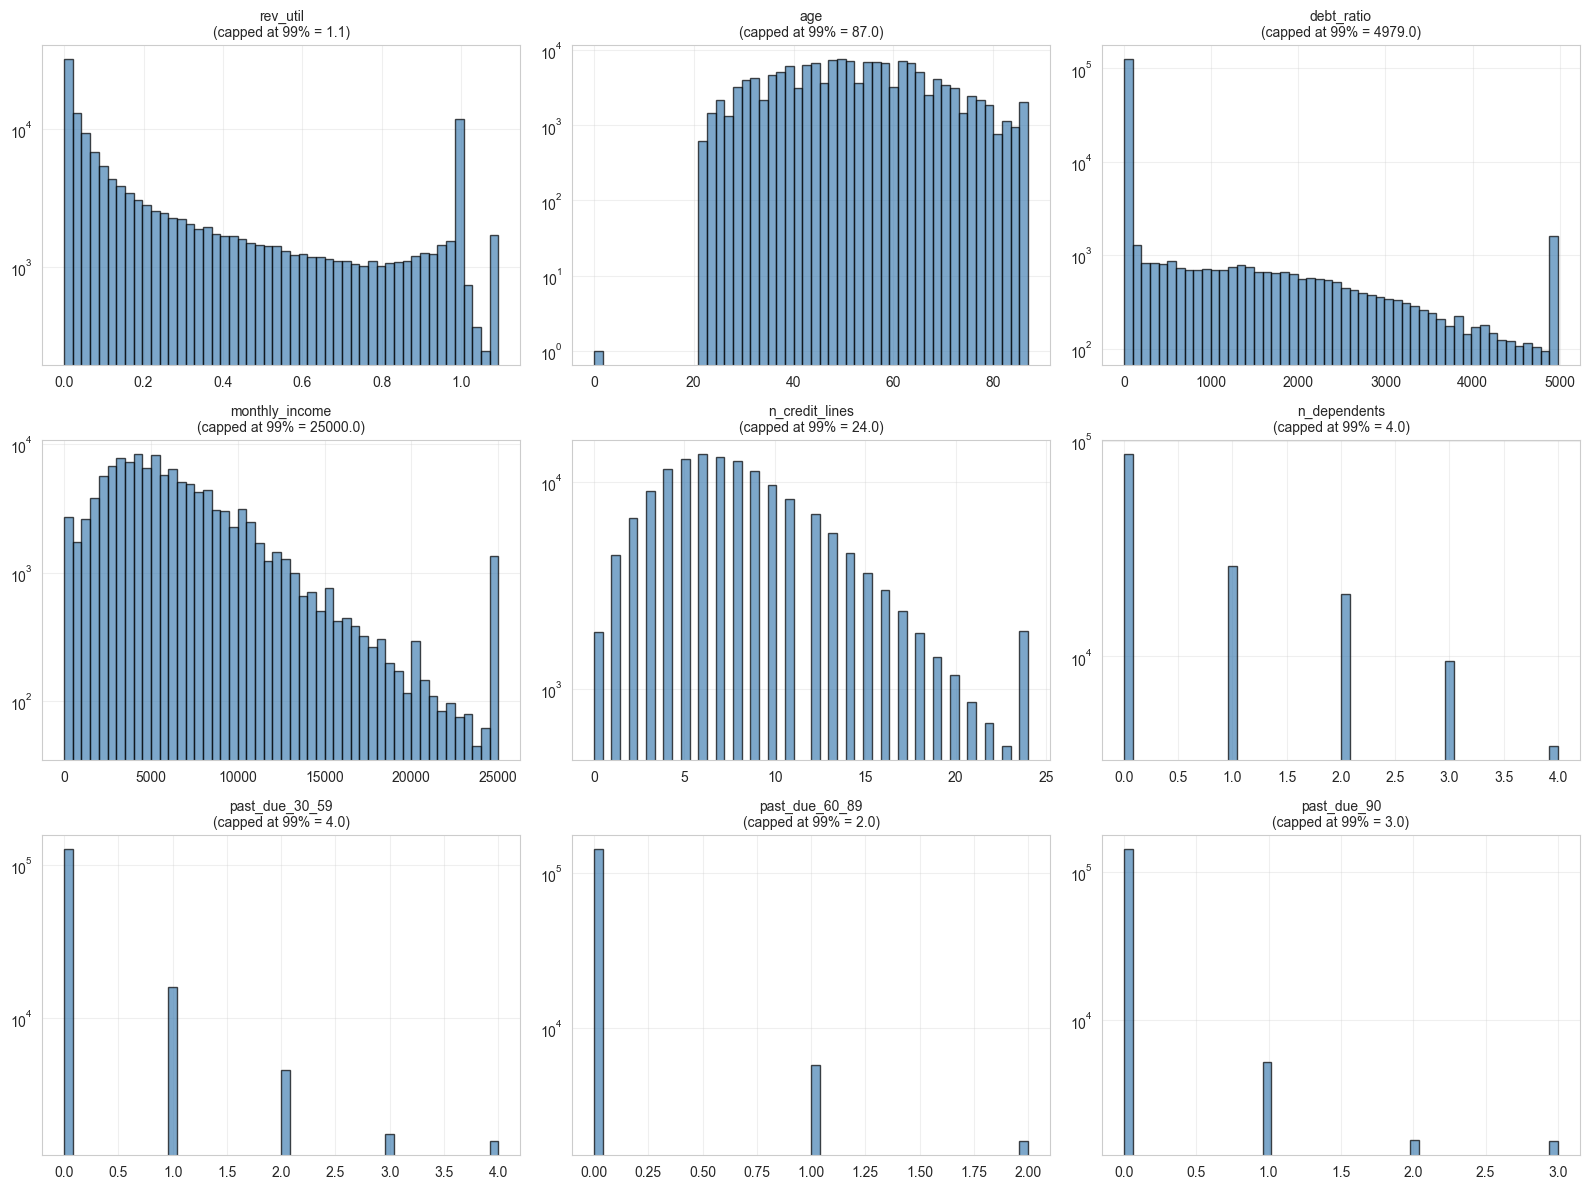

💾 Saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\figures\01_distributions.png


In [22]:
# ===== 4) Plot distributions =====
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

plot_cols = [
    "rev_util", "age", "debt_ratio",
    "monthly_income", "n_credit_lines", "n_dependents",
    "past_due_30_59", "past_due_60_89", "past_due_90",
]

for ax, col in zip(axes.flatten(), plot_cols):
    # ใช้ log scale + winsorize ที่ 99% เพื่อให้เห็น distribution ชัด
    data = df[col].dropna()
    upper = data.quantile(0.99)
    data_capped = data.clip(upper=upper)
    
    ax.hist(data_capped, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
    ax.set_title(f"{col}\n(capped at 99% = {upper:.1f})", fontsize=10)
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_distributions.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {FIG_DIR / '01_distributions.png'}")

📊 Default Rate by Feature Bins (Risk Profiling)


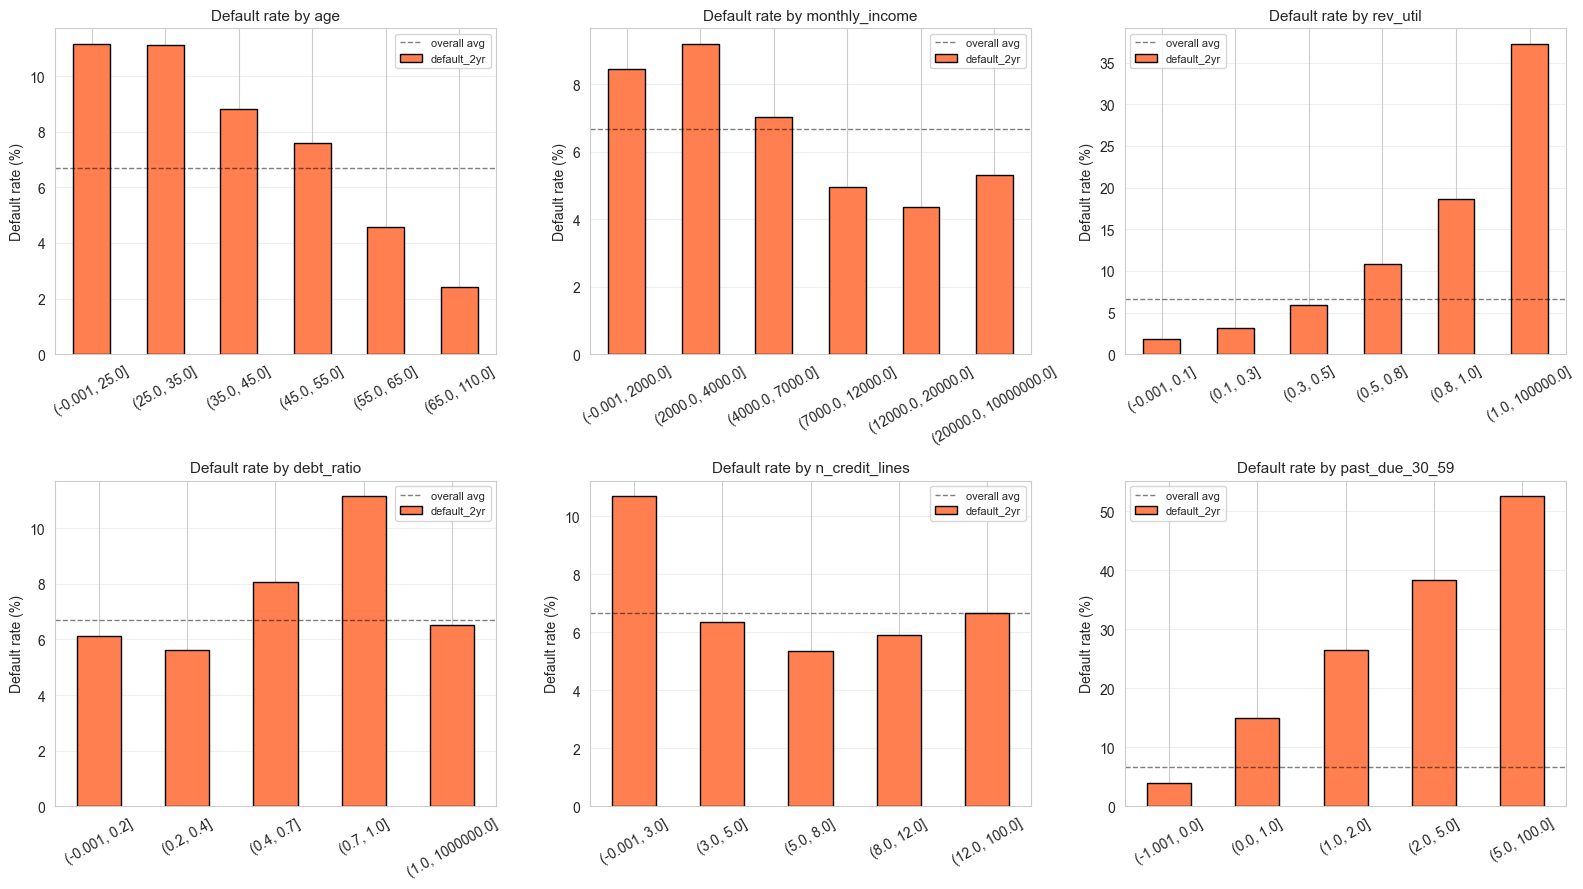

💾 Saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\figures\02_default_by_bins.png


In [23]:
# ===== 5) Default rate by feature bins =====
print("=" * 60)
print("📊 Default Rate by Feature Bins (Risk Profiling)")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

bin_specs = [
    ("age",            [0, 25, 35, 45, 55, 65, 110]),
    ("monthly_income", [0, 2000, 4000, 7000, 12000, 20000, 1e7]),
    ("rev_util",       [0, 0.1, 0.3, 0.5, 0.8, 1.0, 1e5]),
    ("debt_ratio",     [0, 0.2, 0.4, 0.7, 1.0, 1e6]),
    ("n_credit_lines", [0, 3, 5, 8, 12, 100]),
    ("past_due_30_59", [-1, 0, 1, 2, 5, 100]),
]

for ax, (col, bins) in zip(axes.flatten(), bin_specs):
    binned = pd.cut(df[col], bins=bins, include_lowest=True)
    rate = df.groupby(binned)["default_2yr"].mean() * 100
    rate.plot(kind="bar", ax=ax, color="coral", edgecolor="black")
    ax.set_title(f"Default rate by {col}", fontsize=11)
    ax.set_ylabel("Default rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.axhline(df["default_2yr"].mean() * 100, color="black", linestyle="--", linewidth=1, alpha=0.5, label="overall avg")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_default_by_bins.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {FIG_DIR / '02_default_by_bins.png'}")

In [24]:
# ===== Updated Action Plan based on EDA findings =====
FE_PLAN = {
    "remove": [
        "age < 18 (14 rows) — data error",
    ],
    "special_code_handling": [
        "past_due_30_59/60_89/90 = 96/98 → สร้าง flag ก่อนแทน",
        "ใน 269 rows นี้ default rate = 54.65% — เก็บไว้เป็น feature สำคัญ",
    ],
    "winsorize_outliers": [
        "rev_util > 1.0 → cap ที่ 1.0 (เกินคือ data error)",
        "monthly_income > p99.5 (~25,000) → cap",
        "debt_ratio > 1 → ไม่ใช่ debt_ratio จริง — แยกเป็นอีก feature",
    ],
    "create_flags": [
        "credit_maxed = (rev_util ≥ 0.95)",         # จาก spike ที่ 1.0
        "income_missing = monthly_income.isnull()", # 80% overlap กับ debt_ratio>1
        "any_past_due = (past_due_30_59 > 0) | ...", # lift 3.33
        "has_special_code = (past_due_30_59 ≥ 96)", # lift 8.18!!!
        "income_zero = (monthly_income == 0)",
    ],
    "impute": [
        "monthly_income → median ตาม age_group (ไม่ใช่ overall median)",
        "n_dependents → 0",
    ],
    "transform": [
        "log(monthly_income + 1) — right-skewed",
        "log(debt_ratio + 1) — เฉพาะกลุ่ม ≤ 1",
    ],
    "derive_new": [
        "age_bin → categorical (จากกราฟเห็นว่า monotonic)",
        "total_past_due = sum ของ 3 columns",
        "debt_per_credit_line = debt_ratio / (n_credit_lines + 1)",
        "income_per_dependent = monthly_income / (n_dependents + 1)",
    ],
}

import json
print("=" * 60)
print("📋 Feature Engineering Plan (อัปเดตจาก EDA)")
print("=" * 60)
print(json.dumps(FE_PLAN, indent=2, ensure_ascii=False))

CONFIG["fe_plan"] = FE_PLAN

📋 Feature Engineering Plan (อัปเดตจาก EDA)
{
  "remove": [
    "age < 18 (14 rows) — data error"
  ],
  "special_code_handling": [
    "past_due_30_59/60_89/90 = 96/98 → สร้าง flag ก่อนแทน",
    "ใน 269 rows นี้ default rate = 54.65% — เก็บไว้เป็น feature สำคัญ"
  ],
  "winsorize_outliers": [
    "rev_util > 1.0 → cap ที่ 1.0 (เกินคือ data error)",
    "monthly_income > p99.5 (~25,000) → cap",
    "debt_ratio > 1 → ไม่ใช่ debt_ratio จริง — แยกเป็นอีก feature"
  ],
  "create_flags": [
    "credit_maxed = (rev_util ≥ 0.95)",
    "income_missing = monthly_income.isnull()",
    "any_past_due = (past_due_30_59 > 0) | ...",
    "has_special_code = (past_due_30_59 ≥ 96)",
    "income_zero = (monthly_income == 0)"
  ],
  "impute": [
    "monthly_income → median ตาม age_group (ไม่ใช่ overall median)",
    "n_dependents → 0"
  ],
  "transform": [
    "log(monthly_income + 1) — right-skewed",
    "log(debt_ratio + 1) — เฉพาะกลุ่ม ≤ 1"
  ],
  "derive_new": [
    "age_bin → categorical (จากกราฟเห็น

Cell 5 — Correlation Analysis + Preliminary Feature Importance
ก่อนทำ FE มาดูว่า feature ไหนสัมพันธ์กับ target และกันเอง
- ป้องกัน multi-collinearity
- คาดเดาว่า feature ไหนจะสำคัญ

In [25]:
# ===== 1) Correlation with target (Spearman เพราะ non-linear) =====
from scipy.stats import spearmanr

# replace special code 96/98 ก่อนคำนวณ correlation (ชั่วคราว)
df_corr = df.copy()
for col in ["past_due_30_59", "past_due_60_89", "past_due_90"]:
    df_corr[col] = df_corr[col].replace([96, 98], np.nan)

# Compute correlation
corr_target = []
for col in CONFIG["feature_cols"]:
    valid = df_corr[[col, "default_2yr"]].dropna()
    if len(valid) > 100:
        rho, pval = spearmanr(valid[col], valid["default_2yr"])
        corr_target.append({
            "feature":    col,
            "spearman":   round(rho, 4),
            "abs_corr":   round(abs(rho), 4),
            "p_value":    pval,
            "direction":  "↑ Risk" if rho > 0 else "↓ Risk",
        })

corr_df = pd.DataFrame(corr_target).sort_values("abs_corr", ascending=False)
display(corr_df)

print("\n💡 Top 3 strongest predictors:")
for _, row in corr_df.head(3).iterrows():
    print(f"   • {row['feature']:20s} | ρ = {row['spearman']:+.3f} | {row['direction']}")

,feature,spearman,abs_corr,p_value,direction
6,past_due_90,0.3354,0.3354,0.000000e+00,↑ Risk
8,past_due_60_89,0.2683,0.2683,0.000000e+00,↑ Risk
2,past_due_30_59,0.2514,0.2514,0.000000e+00,↑ Risk
0,rev_util,0.2404,0.2404,0.000000e+00,↑ Risk
1,age,-0.1170,0.1170,0.000000e+00,↓ Risk
4,monthly_income,-0.0670,0.0670,1.285960e-119,↓ Risk
9,n_dependents,0.0460,0.0460,3.525264e-69,↑ Risk
5,n_credit_lines,-0.0386,0.0386,1.555674e-50,↓ Risk
7,n_real_estate,-0.0341,0.0341,6.933016e-40,↓ Risk
3,debt_ratio,0.0206,0.0206,1.488452e-15,↑ Risk



💡 Top 3 strongest predictors:
   • past_due_90          | ρ = +0.335 | ↑ Risk
   • past_due_60_89       | ρ = +0.268 | ↑ Risk
   • past_due_30_59       | ρ = +0.251 | ↑ Risk


🔗 Feature-to-Feature Correlation (Multi-collinearity Check)


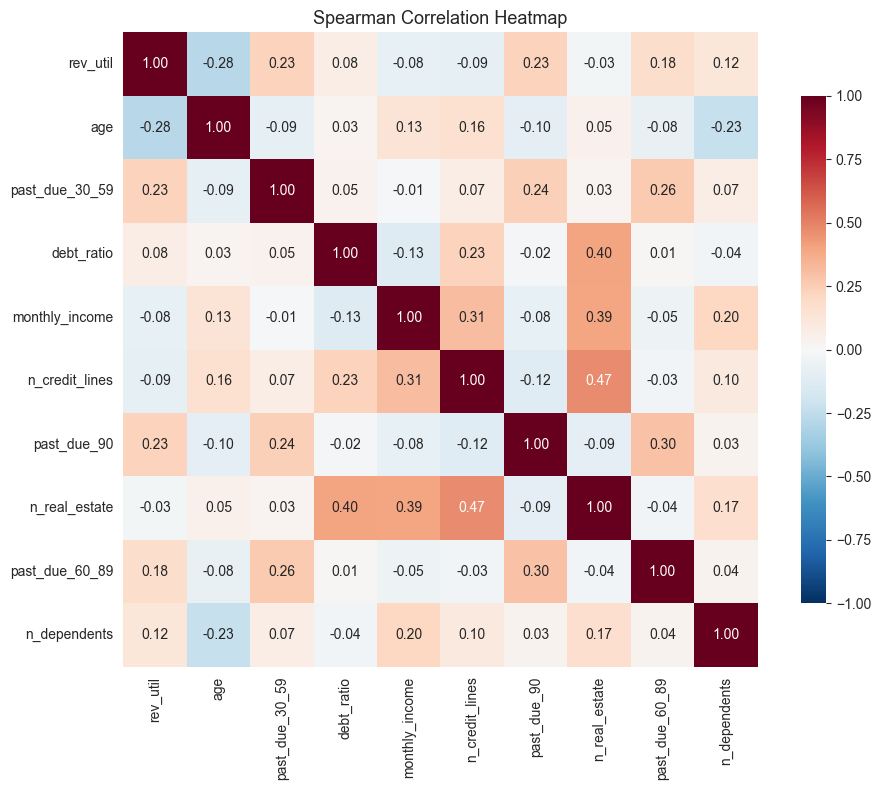


🚨 Highly correlated feature pairs (|ρ| > 0.5):
   ✅ ไม่พบ pair ที่ correlation สูง — features independent ดี


In [26]:
# ===== 2) Multi-collinearity check =====
print("=" * 60)
print("🔗 Feature-to-Feature Correlation (Multi-collinearity Check)")
print("=" * 60)

corr_matrix = df_corr[CONFIG["feature_cols"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Spearman Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_correlation_heatmap.png", dpi=100, bbox_inches="tight")
plt.show()

# Find high-correlation pairs
print("\n🚨 Highly correlated feature pairs (|ρ| > 0.5):")
pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        rho = corr_matrix.iloc[i, j]
        if abs(rho) > 0.5:
            pairs.append((cols[i], cols[j], round(rho, 3)))

if pairs:
    for p in pairs:
        print(f"   • {p[0]:20s} ↔ {p[1]:20s} | ρ = {p[2]:+.3f}")
else:
    print("   ✅ ไม่พบ pair ที่ correlation สูง — features independent ดี")

📊 Mutual Information with target (จับ non-linear)


,feature,MI_score
0,rev_util,0.0346
6,past_due_90,0.0301
2,past_due_30_59,0.0251
8,past_due_60_89,0.0200
1,age,0.0062
7,n_real_estate,0.0052
4,monthly_income,0.0040
3,debt_ratio,0.0040
5,n_credit_lines,0.0035
9,n_dependents,0.0027


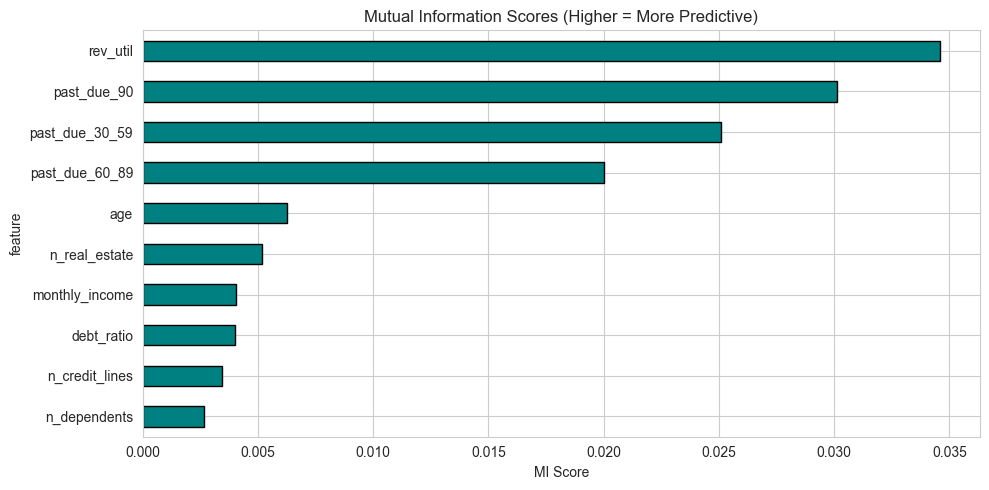

In [27]:
# ===== 3) Mutual Information (จับ non-linear relationship) =====
from sklearn.feature_selection import mutual_info_classif

# Use only complete rows for MI calculation
df_mi = df_corr.dropna()
X_mi = df_mi[CONFIG["feature_cols"]]
y_mi = df_mi["default_2yr"]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    "feature": CONFIG["feature_cols"],
    "MI_score": mi_scores,
}).sort_values("MI_score", ascending=False)

print("=" * 60)
print("📊 Mutual Information with target (จับ non-linear)")
print("=" * 60)
display(mi_df.round(4))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
mi_df.set_index("feature")["MI_score"].plot(kind="barh", ax=ax, color="teal", edgecolor="black")
ax.set_title("Mutual Information Scores (Higher = More Predictive)")
ax.set_xlabel("MI Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_mutual_information.png", dpi=100, bbox_inches="tight")
plt.show()


Cell 6 — Save Feature Engineering Plan + Pre-FE Checkpoint
EDA insights ทั้งหมด เราได้แผน FE แล้ว — มา save plan + 
snapshot DataFrame ก่อนทำ FE เผื่อ rollback

In [28]:
# ===== Updated FE Plan (จาก Cell 4 + 5 insights) =====
FE_PLAN = {
    "remove_rows": {
        "condition":  "age < 18 or age > 100",
        "expected_n": 14,
        "reason":     "Data error — ไม่มีคนกู้เงินอายุ 0",
    },

    "special_code_handling": {
        "columns": ["past_due_30_59", "past_due_60_89", "past_due_90"],
        "codes":   [96, 98],
        "action":  "1) สร้าง flag 'has_special_code' ก่อน, 2) แทนด้วย median",
        "reason":  "269 rows นี้ default rate = 54.65% (lift 8.18) → keep as signal!",
    },

    "winsorize": {
        "rev_util":       {"upper": 1.0, "method": "clip"},
        "monthly_income": {"upper": "p99.5", "method": "clip"},
    },

    "create_flags": [
        {"name": "credit_maxed",     "expr": "rev_util >= 0.95",
         "rationale": "rev_util spike at 1.0 + non-linear relationship from MI"},
        {"name": "any_past_due",     "expr": "(past_due_30_59 > 0) | (past_due_60_89 > 0) | (past_due_90 > 0)",
         "rationale": "Lift 3.33 — strongest binary signal"},
        {"name": "has_special_code", "expr": "past_due_30_59 >= 96",
         "rationale": "Lift 8.18 — strongest signal of all"},
        {"name": "income_missing",   "expr": "monthly_income.isnull()",
         "rationale": "79.4% overlap with debt_ratio > 1 → separate signal"},
        {"name": "income_zero",      "expr": "monthly_income == 0",
         "rationale": "1,634 rows — possible unemployed signal"},
    ],

    "impute": {
        "monthly_income": "median per age_bin (NOT overall median)",
        "n_dependents":   0,
    },

    "transform": {
        "monthly_income_log": "log1p(monthly_income)",
        "debt_ratio_log":     "log1p(debt_ratio) — for debt_ratio ≤ 1 only",
    },

    "derive_features": [
        {"name": "age_bin",              "method": "cut into [0,25,35,45,55,65,110]"},
        {"name": "total_past_due",       "method": "past_due_30_59 + 60_89 + 90 (after clean)"},
        {"name": "debt_per_credit_line", "method": "debt_ratio / (n_credit_lines + 1)"},
        {"name": "income_per_dependent", "method": "monthly_income / (n_dependents + 1)"},
    ],

    "drop_after_fe": [
        "raw past_due_* (มี _clean version แล้ว)",
        "raw monthly_income (มี _log version แล้ว)",
    ],
}

# Save to CONFIG
CONFIG["fe_plan"] = FE_PLAN

import json
print("=" * 70)
print("📋 Final FE Plan (จาก EDA insights ทั้งหมด)")
print("=" * 70)
print(json.dumps(FE_PLAN, indent=2, ensure_ascii=False))

📋 Final FE Plan (จาก EDA insights ทั้งหมด)
{
  "remove_rows": {
    "condition": "age < 18 or age > 100",
    "expected_n": 14,
    "reason": "Data error — ไม่มีคนกู้เงินอายุ 0"
  },
  "special_code_handling": {
    "columns": [
      "past_due_30_59",
      "past_due_60_89",
      "past_due_90"
    ],
    "codes": [
      96,
      98
    ],
    "action": "1) สร้าง flag 'has_special_code' ก่อน, 2) แทนด้วย median",
    "reason": "269 rows นี้ default rate = 54.65% (lift 8.18) → keep as signal!"
  },
  "winsorize": {
    "rev_util": {
      "upper": 1.0,
      "method": "clip"
    },
    "monthly_income": {
      "upper": "p99.5",
      "method": "clip"
    }
  },
  "create_flags": [
    {
      "name": "credit_maxed",
      "expr": "rev_util >= 0.95",
      "rationale": "rev_util spike at 1.0 + non-linear relationship from MI"
    },
    {
      "name": "any_past_due",
      "expr": "(past_due_30_59 > 0) | (past_due_60_89 > 0) | (past_due_90 > 0)",
      "rationale": "Lift 3.33 — stron

In [29]:
# ===== Snapshot df ก่อนทำ FE (เผื่อ rollback) =====
df_pre_fe = df.copy()

# Save to parquet ด้วยเผื่อใช้ภายหลัง
df_pre_fe.to_parquet(RESULT_DIR / "df_pre_fe.parquet")

print(f"\n✅ Snapshot บันทึก: {RESULT_DIR / 'df_pre_fe.parquet'}")
print(f"   Shape: {df_pre_fe.shape}")
print(f"   Memory: {df_pre_fe.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


✅ Snapshot บันทึก: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\results\df_pre_fe.parquet
   Shape: (150000, 11)
   Memory: 13.73 MB


Cell 7 — Feature Engineering Implementation
 ทำตาม FE_PLAN ที่วางไว้ ทีละขั้น แบบ traceable

In [30]:
# ===== Feature Engineering Pipeline =====

def feature_engineer(df_input: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """
    Apply feature engineering ตาม FE_PLAN
    
    Steps:
        1. Remove rows ที่ age invalid
        2. Create flags ก่อนทำอะไรกับ raw values
        3. Handle special codes
        4. Winsorize outliers
        5. Impute missing
        6. Transform skewed features
        7. Derive new features
    """
    df = df_input.copy()
    log = []
    initial_n = len(df)

    # ===== Step 1: Remove invalid age =====
    mask_valid_age = (df["age"] >= 18) & (df["age"] <= 100)
    df = df[mask_valid_age].copy()
    log.append(f"1️⃣ Remove invalid age: {initial_n - len(df)} rows removed")

    # ===== Step 2: Create flags (BEFORE modifying raw values!) =====
    df["flag_credit_maxed"]     = (df["rev_util"] >= 0.95).astype(int)
    df["flag_any_past_due"]     = (
        (df["past_due_30_59"] > 0) | 
        (df["past_due_60_89"] > 0) | 
        (df["past_due_90"] > 0)
    ).astype(int)
    df["flag_special_code"]     = (df["past_due_30_59"] >= 96).astype(int)
    df["flag_income_missing"]   = df["monthly_income"].isnull().astype(int)
    df["flag_income_zero"]      = (df["monthly_income"] == 0).astype(int)
    log.append(f"2️⃣ Created 5 binary flags")

    # ===== Step 3: Replace special codes 96/98 with median =====
    for col in ["past_due_30_59", "past_due_60_89", "past_due_90"]:
        median_val = df.loc[~df[col].isin([96, 98]), col].median()
        df[col] = df[col].replace([96, 98], median_val)
    log.append(f"3️⃣ Replaced special codes 96/98 with median")

    # ===== Step 4: Winsorize outliers =====
    df["rev_util"] = df["rev_util"].clip(upper=1.0)
    
    income_cap = df["monthly_income"].quantile(0.995)
    df["monthly_income"] = df["monthly_income"].clip(upper=income_cap)
    log.append(f"4️⃣ Winsorized: rev_util→[0,1], income→[0, {income_cap:,.0f}]")

    # ===== Step 5: Impute missing =====
    # 5a) monthly_income: median per age_bin (smarter than overall median)
    df["age_bin"] = pd.cut(df["age"], 
                            bins=[0, 25, 35, 45, 55, 65, 110],
                            labels=["<25", "25-35", "35-45", "45-55", "55-65", "65+"])
    
    income_median_per_age = df.groupby("age_bin", observed=True)["monthly_income"].transform("median")
    df["monthly_income"] = df["monthly_income"].fillna(income_median_per_age)
    
    # 5b) n_dependents: fill with 0
    df["n_dependents"] = df["n_dependents"].fillna(0)
    log.append(f"5️⃣ Imputed: income (median by age_bin), n_dependents → 0")

    # ===== Step 6: Log transform skewed features =====
    df["monthly_income_log"] = np.log1p(df["monthly_income"])
    df["debt_ratio_log"]     = np.log1p(df["debt_ratio"].clip(lower=0))
    log.append(f"6️⃣ Log-transformed: monthly_income, debt_ratio")

    # ===== Step 7: Derive new features =====
    df["total_past_due"] = (
        df["past_due_30_59"] + df["past_due_60_89"] + df["past_due_90"]
    )

    df["debt_per_credit_line"] = (
        df["debt_ratio"] / (df["n_credit_lines"] + 1)
    )

    df["income_per_dependent"] = (
        df["monthly_income"] / (df["n_dependents"] + 1)
    )
    
    # Encode age_bin → one-hot
    df = pd.get_dummies(df, columns=["age_bin"], prefix="age", drop_first=True, dtype=int)
    
    log.append(f"7️⃣ Derived 3 new features + age_bin one-hot")

    # Summary
    if verbose:
        print("=" * 60)
        print("🛠️  Feature Engineering Log")
        print("=" * 60)
        for line in log:
            print(f"   {line}")
        print(f"\n📊 Final shape: {df.shape}")
        print(f"📈 Features grown: {df_input.shape[1]} → {df.shape[1]}")

    return df


# Apply FE
df_fe = feature_engineer(df, verbose=True)

# Show new columns
new_cols = sorted(set(df_fe.columns) - set(df.columns))
print(f"\n🆕 New columns ({len(new_cols)}):")
for c in new_cols:
    print(f"   • {c}")

🛠️  Feature Engineering Log
   1️⃣ Remove invalid age: 14 rows removed
   2️⃣ Created 5 binary flags
   3️⃣ Replaced special codes 96/98 with median
   4️⃣ Winsorized: rev_util→[0,1], income→[0, 35,000]
   5️⃣ Imputed: income (median by age_bin), n_dependents → 0
   6️⃣ Log-transformed: monthly_income, debt_ratio
   7️⃣ Derived 3 new features + age_bin one-hot

📊 Final shape: (149986, 26)
📈 Features grown: 11 → 26

🆕 New columns (15):
   • age_25-35
   • age_35-45
   • age_45-55
   • age_55-65
   • age_65+
   • debt_per_credit_line
   • debt_ratio_log
   • flag_any_past_due
   • flag_credit_maxed
   • flag_income_missing
   • flag_income_zero
   • flag_special_code
   • income_per_dependent
   • monthly_income_log
   • total_past_due


🔍 Verify FE Results

In [32]:
# ===== Verify =====
print("=" * 70)
print("✅ Verification")
print("=" * 70)

# Check 1: ไม่มี NaN เหลือ (ยกเว้น flags)
nan_cols = df_fe.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
if len(nan_cols) == 0:
    print("✅ ไม่มี NaN เหลือ")
else:
    print(f"⚠️ ยังมี NaN ใน:\n{nan_cols}")

# Check 2: rev_util ใน [0, 1]
print(f"\n✅ rev_util range: [{df_fe['rev_util'].min():.2f}, {df_fe['rev_util'].max():.2f}]")

# Check 3: special codes ถูกแทนหมด
for col in ["past_due_30_59", "past_due_60_89", "past_due_90"]:
    has_special = (df_fe[col] >= 96).sum()
    print(f"✅ {col}: special codes remaining = {has_special}")

# Check 4: Flag distributions
print(f"\n🚩 Flag Distributions:")
flag_cols = [c for c in df_fe.columns if c.startswith("flag_")]
flag_summary = df_fe[flag_cols].mean() * 100
print(flag_summary.round(2).to_string())

# Check 5: New features stats
new_features = ["total_past_due", "debt_per_credit_line", "income_per_dependent",
                "monthly_income_log", "debt_ratio_log"]
print(f"\n📊 New Features Stats:")
display(df_fe[new_features].describe().round(2))

✅ Verification
✅ ไม่มี NaN เหลือ

✅ rev_util range: [0.00, 1.00]
✅ past_due_30_59: special codes remaining = 0
✅ past_due_60_89: special codes remaining = 0
✅ past_due_90: special codes remaining = 0

🚩 Flag Distributions:
flag_credit_maxed      11.46
flag_any_past_due      20.24
flag_special_code       0.18
flag_income_missing    19.82
flag_income_zero        1.09

📊 New Features Stats:


,total_past_due,debt_per_credit_line,income_per_dependent,monthly_income_log,debt_ratio_log
count,149986.0,149986.00,149986.00,149986.00,149986.00
mean,0.4,41.13,4479.32,8.44,1.53
std,1.1,225.09,3443.53,1.20,2.63
min,0.0,0.00,0.00,0.00,0.00
25%,0.0,0.02,2104.25,8.26,0.16
50%,0.0,0.04,3876.00,8.63,0.31
75%,0.0,0.10,6100.00,8.91,0.62
max,19.0,46634.57,35000.00,10.46,12.71


Default Rate by New Flags — ตรวจสอบว่า feature ใหม่ใช้ได้จริงไหม

In [33]:
# ===== Validate new flags =====
print("=" * 60)
print("🎯 Default Rate per Flag (เพื่อ verify ว่า feature ใหม่มีพลัง)")
print("=" * 60)

flag_lift = []
overall_rate = df_fe["default_2yr"].mean() * 100

for flag in flag_cols + ["any_past_due" if "any_past_due" in df_fe.columns else None]:
    if flag is None or flag not in df_fe.columns:
        continue
    
    rate_1 = df_fe.loc[df_fe[flag] == 1, "default_2yr"].mean() * 100
    rate_0 = df_fe.loc[df_fe[flag] == 0, "default_2yr"].mean() * 100
    n_pos  = (df_fe[flag] == 1).sum()
    
    flag_lift.append({
        "flag":          flag,
        "n_positive":    n_pos,
        "default_if_1":  round(rate_1, 2),
        "default_if_0":  round(rate_0, 2),
        "lift":          round(rate_1 / overall_rate, 2),
    })

lift_df = pd.DataFrame(flag_lift).sort_values("lift", ascending=False)
display(lift_df)

print(f"\n💡 Overall default rate (baseline) = {overall_rate:.2f}%")
print(f"   Lift > 1 = flag identify high-risk group")

🎯 Default Rate per Flag (เพื่อ verify ว่า feature ใหม่มีพลัง)


,flag,n_positive,default_if_1,default_if_0,lift
2,flag_special_code,269,54.65,6.60,8.18
0,flag_credit_maxed,17184,22.86,4.59,3.42
1,flag_any_past_due,30361,22.27,2.73,3.33
3,flag_income_missing,29724,5.61,6.95,0.84
4,flag_income_zero,1634,4.04,6.71,0.60



💡 Overall default rate (baseline) = 6.68%
   Lift > 1 = flag identify high-risk group


In [34]:
# ===== Save =====
df_fe.to_parquet(RESULT_DIR / "df_post_fe.parquet")
print(f"✅ Saved: {RESULT_DIR / 'df_post_fe.parquet'}")
print(f"   Shape: {df_fe.shape}")
print(f"   Memory: {df_fe.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✅ Saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\results\df_post_fe.parquet
   Shape: (149986, 26)
   Memory: 25.17 MB


Cell 8 — Train/Test Split + Pre-modeling Setup

Strategy
- **Stratified split** (80/20) เพื่อให้ default rate เท่ากันใน train/test
- **Define feature groups** สำหรับใช้กับ different models
- **Setup CV strategy** (5-fold stratified) สำหรับ comparison

In [35]:
# ===== 1) Define feature sets =====
target = "default_2yr"

# Features ทั้งหมดที่จะใช้ (exclude target)
# ลบ raw past_due_* ออกเพราะข้อมูลถูก capture ผ่าน flag + total แล้ว
# แต่ keep ไว้ก่อนสำหรับ tree-based models (RF/LGB จัดการ correlation ได้)
all_features = [c for c in df_fe.columns if c != target]

print(f"📊 Total features available: {len(all_features)}")
print(f"\n📋 Feature inventory:")

feature_inventory = {
    "demographic":    ["age"] + [c for c in df_fe.columns if c.startswith("age_")],
    "financial":      ["monthly_income", "monthly_income_log", "debt_ratio", "debt_ratio_log", 
                       "rev_util", "income_per_dependent"],
    "credit":         ["n_credit_lines", "n_real_estate", "debt_per_credit_line"],
    "delinquency":    ["past_due_30_59", "past_due_60_89", "past_due_90", "total_past_due"],
    "household":      ["n_dependents"],
    "flags":          [c for c in df_fe.columns if c.startswith("flag_")],
}

for group, cols in feature_inventory.items():
    valid_cols = [c for c in cols if c in df_fe.columns]
    print(f"   {group:15s}: {len(valid_cols)} features → {valid_cols}")

CONFIG["feature_inventory"] = feature_inventory
CONFIG["all_features"]      = all_features

📊 Total features available: 25

📋 Feature inventory:
   demographic    : 6 features → ['age', 'age_25-35', 'age_35-45', 'age_45-55', 'age_55-65', 'age_65+']
   financial      : 6 features → ['monthly_income', 'monthly_income_log', 'debt_ratio', 'debt_ratio_log', 'rev_util', 'income_per_dependent']
   credit         : 3 features → ['n_credit_lines', 'n_real_estate', 'debt_per_credit_line']
   delinquency    : 4 features → ['past_due_30_59', 'past_due_60_89', 'past_due_90', 'total_past_due']
   household      : 1 features → ['n_dependents']
   flags          : 5 features → ['flag_credit_maxed', 'flag_any_past_due', 'flag_special_code', 'flag_income_missing', 'flag_income_zero']


In [36]:
# ===== 2) Split X, y =====
X = df_fe[all_features].copy()
y = df_fe[target].copy()

print(f"\n📐 X shape: {X.shape}")
print(f"📐 y shape: {y.shape}")
print(f"📐 y distribution:")
print(y.value_counts(normalize=True).round(4) * 100)


📐 X shape: (149986, 25)
📐 y shape: (149986,)
📐 y distribution:
default_2yr
0    93.32
1     6.68
Name: proportion, dtype: float64


In [38]:
# ===== 3) Stratified Train/Test Split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,           # ⭐ สำคัญสำหรับ imbalanced data
)

print("=" * 60)
print("🔀 Train/Test Split (Stratified 80/20)")
print("=" * 60)

split_summary = pd.DataFrame({
    "n_samples":     [len(X_train), len(X_test)],
    "n_default":     [y_train.sum(), y_test.sum()],
    "default_rate":  [
        f"{y_train.mean()*100:.2f}%",
        f"{y_test.mean()*100:.2f}%",
    ],
    "size_pct":      [
        f"{len(X_train)/len(X)*100:.1f}%",
        f"{len(X_test)/len(X)*100:.1f}%",
    ],
}, index=["TRAIN", "TEST"])

display(split_summary)

# Verify stratification
train_rate = y_train.mean() * 100
test_rate  = y_test.mean() * 100
diff = abs(train_rate - test_rate)

if diff < 0.1:
    print(f"\n✅ Stratification successful (diff = {diff:.3f}%)")
else:
    print(f"\n⚠️ Stratification warning (diff = {diff:.3f}%)")

🔀 Train/Test Split (Stratified 80/20)


,n_samples,n_default,default_rate,size_pct
TRAIN,119988,8020,6.68%,80.0%
TEST,29998,2005,6.68%,20.0%



✅ Stratification successful (diff = 0.000%)


4) Setup Cross-Validation Strategy

In [39]:
# ===== 4) CV Strategy =====
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Show CV splits info
print("=" * 60)
print("🔄 Cross-Validation Strategy: Stratified 5-Fold")
print("=" * 60)

fold_info = []
for i, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    fold_info.append({
        "fold":         i,
        "n_train":      len(tr_idx),
        "n_val":        len(val_idx),
        "train_def_rate": f"{y_train.iloc[tr_idx].mean()*100:.2f}%",
        "val_def_rate":   f"{y_train.iloc[val_idx].mean()*100:.2f}%",
    })

cv_summary = pd.DataFrame(fold_info)
display(cv_summary)

print(f"\n✅ Each fold has ~{len(X_train) // 5:,} validation samples")
print(f"✅ Default rate ใกล้เคียงกันทุก fold = stratification works")

🔄 Cross-Validation Strategy: Stratified 5-Fold


,fold,n_train,n_val,train_def_rate,val_def_rate
0,1,95990,23998,6.68%,6.68%
1,2,95990,23998,6.68%,6.68%
2,3,95990,23998,6.68%,6.68%
3,4,95991,23997,6.68%,6.68%
4,5,95991,23997,6.68%,6.68%



✅ Each fold has ~23,997 validation samples
✅ Default rate ใกล้เคียงกันทุก fold = stratification works


5) Pre-modeling Configuration

- **`scale_pos_weight`** สำหรับ XGBoost/LightGBM (handle imbalance)
- **`class_weight='balanced'`** สำหรับ sklearn models
- **`scoring`** metrics ที่จะใช้ compare models

In [40]:
# ===== 5) Model configuration =====
# Calculate scale_pos_weight สำหรับ tree-based models
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("=" * 60)
print("⚙️ Pre-modeling Configuration")
print("=" * 60)
print(f"   • scale_pos_weight (XGB/LGB) : {scale_pos_weight:.2f}")
print(f"   • class_weight (sklearn)     : 'balanced'")
print(f"   • CV strategy                : 5-fold StratifiedKFold")
print(f"   • Random state               : {RANDOM_STATE}")

# Scoring metrics
SCORING_METRICS = {
    "roc_auc":            "ROC-AUC (overall discrimination)",
    "average_precision":  "PR-AUC (focus on minority class)",
    "f1":                 "F1-score (balanced)",
    "recall":             "Recall (catch defaulters)",
    "precision":          "Precision (avoid false alarms)",
}

print(f"\n📊 Metrics for comparison:")
for k, v in SCORING_METRICS.items():
    print(f"   • {k:20s} - {v}")

CONFIG["scale_pos_weight"] = round(scale_pos_weight, 2)
CONFIG["cv_folds"]         = 5
CONFIG["scoring_metrics"]  = list(SCORING_METRICS.keys())

⚙️ Pre-modeling Configuration
   • scale_pos_weight (XGB/LGB) : 13.96
   • class_weight (sklearn)     : 'balanced'
   • CV strategy                : 5-fold StratifiedKFold
   • Random state               : 42

📊 Metrics for comparison:
   • roc_auc              - ROC-AUC (overall discrimination)
   • average_precision    - PR-AUC (focus on minority class)
   • f1                   - F1-score (balanced)
   • recall               - Recall (catch defaulters)
   • precision            - Precision (avoid false alarms)


6) Helper Functions สำหรับ evaluation

In [41]:
# ===== 6) Helper functions =====
def calc_ks(y_true, y_prob):
    """KS statistic = max separation between cum distributions"""
    df_ks = pd.DataFrame({"y": y_true, "p": y_prob}).sort_values("p", ascending=False)
    df_ks["cum_event"]    = (df_ks["y"] == 1).cumsum() / max((df_ks["y"] == 1).sum(), 1)
    df_ks["cum_nonevent"] = (df_ks["y"] == 0).cumsum() / max((df_ks["y"] == 0).sum(), 1)
    return (df_ks["cum_event"] - df_ks["cum_nonevent"]).max()


def evaluate_model(model, X_test, y_test, name=""):
    """ประเมินโมเดลด้วย metrics ทั้งหมดของวงการ credit risk"""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    return {
        "Model":     name,
        "ROC_AUC":   round(auc, 4),
        "Gini":      round(2 * auc - 1, 4),
        "KS":        round(calc_ks(y_test, y_prob), 4),
        "PR_AUC":    round(average_precision_score(y_test, y_prob), 4),
        "F1":        round(f1_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
    }


def plot_confusion(y_test, y_pred, name=""):
    """Plot confusion matrix สวยๆ"""
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Non-default", "Default"],
        yticklabels=["Non-default", "Default"],
    )
    
    # Add percentages
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.7, f"({cm_pct[i,j]:.1f}%)",
                    ha="center", va="center", fontsize=9, color="gray")
    
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    return fig


print("✅ Helper functions defined: evaluate_model(), calc_ks(), plot_confusion()")
print("\n🚀 Ready for model training!")

✅ Helper functions defined: evaluate_model(), calc_ks(), plot_confusion()

🚀 Ready for model training!


Cell 9 — Model 1: Logistic Regression + Lasso (L1)

🎯 ทำไมเริ่มจากตัวนี้?
1. **Interpretable baseline** — สมการตรงไปตรงมา ใช้ทำ scorecard ได้
2. **Auto feature selection** — L1 penalty บีบ coef ที่ไม่สำคัญให้เป็น 0
3. **Industry standard** — แบงค์ส่วนใหญ่ใช้ logistic regression สำหรับ PD model
4. **เปรียบเทียบกับ tree-based** — ดู gap ของ linear vs non-linear

In [42]:
# ===== 1) Build pipeline =====
# Pipeline: StandardScaler → LogisticRegression with L1
# 
# Why pipeline?
# - StandardScaler: Lasso ไวต่อ scale ของ feature
# - L1 (lasso): บีบ coef ให้เป็น 0 อัตโนมัติ
# - class_weight='balanced': จัดการ imbalance
# - solver='liblinear': รองรับ L1 ดีที่สุดสำหรับ binary

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.1,                          # regularization strength (smaller = stronger penalty)
        class_weight="balanced",         # handle imbalance
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

# ===== 2) Train =====
print("=" * 60)
print("🔵 Training: Logistic Regression + Lasso (L1)")
print("=" * 60)

import time
t0 = time.time()
lr_pipeline.fit(X_train, y_train)
train_time = time.time() - t0

print(f"✅ Training complete in {train_time:.2f} seconds")

🔵 Training: Logistic Regression + Lasso (L1)
✅ Training complete in 15.08 seconds


In [43]:
# ===== 3) Evaluate on test set =====
print("\n" + "=" * 60)
print("📊 Test Set Performance")
print("=" * 60)

result_lr = evaluate_model(lr_pipeline, X_test, y_test, name="Logistic + Lasso")

for k, v in result_lr.items():
    if k != "Model":
        print(f"   {k:12s}: {v}")


📊 Test Set Performance
   ROC_AUC     : 0.8665
   Gini        : 0.733
   KS          : 0.5797
   PR_AUC      : 0.3956
   F1          : 0.3383
   Recall      : 0.7691
   Precision   : 0.2168


🎯 Feature Selection จาก L1 Penalty
Lasso จะ **บีบ coefficient ของ feature ที่ไม่สำคัญให้เป็น 0** อัตโนมัติ
ดูว่าเหลือกี่ตัวจากทั้งหมด 25 ตัว

In [44]:
# ===== 4) Lasso feature selection result =====
coefs = lr_pipeline.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "feature":     X_train.columns,
    "coefficient": coefs,
    "abs_coef":    np.abs(coefs),
    "direction":   ["↑ Risk" if c > 0 else ("↓ Risk" if c < 0 else "—") for c in coefs],
}).sort_values("abs_coef", ascending=False)

n_selected = (coefs != 0).sum()
n_dropped  = (coefs == 0).sum()

print("=" * 70)
print(f"🎯 Lasso Feature Selection: {n_selected}/{len(coefs)} features selected")
print(f"   {n_dropped} features dropped (coef = 0)")
print("=" * 70)

print("\n📌 Selected features (ranked by importance):")
display(coef_df[coef_df["abs_coef"] > 0].round(4))

if n_dropped > 0:
    print(f"\n❌ Dropped features (Lasso ตัดทิ้ง):")
    print(coef_df[coef_df["abs_coef"] == 0]["feature"].tolist())

🎯 Lasso Feature Selection: 24/25 features selected
   1 features dropped (coef = 0)

📌 Selected features (ranked by importance):


,feature,coefficient,abs_coef,direction
0,rev_util,0.7274,0.7274,↑ Risk
11,flag_any_past_due,0.4159,0.4159,↑ Risk
6,past_due_90,0.2269,0.2269,↑ Risk
17,total_past_due,0.2103,0.2103,↑ Risk
5,n_credit_lines,0.1937,0.1937,↑ Risk
7,n_real_estate,0.1567,0.1567,↑ Risk
4,monthly_income,-0.1474,0.1474,↓ Risk
24,age_65+,-0.1470,0.1470,↓ Risk
1,age,-0.1467,0.1467,↓ Risk
8,past_due_60_89,0.1422,0.1422,↑ Risk



❌ Dropped features (Lasso ตัดทิ้ง):
['past_due_30_59']


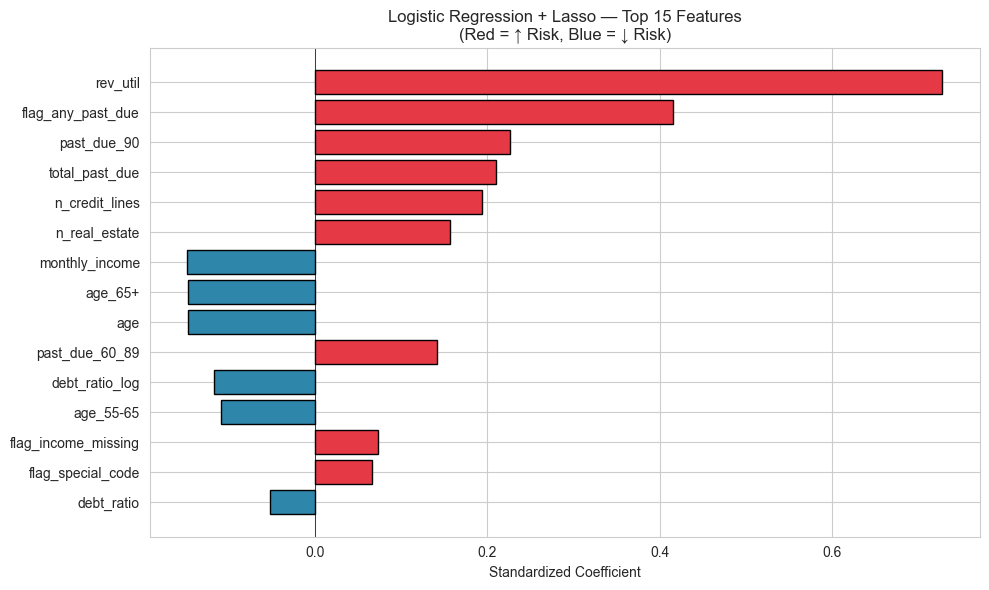

💾 Saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\figures\05_lr_coefficients.png


In [45]:
# ===== 5) Plot top features =====
top_n = 15
top_features = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E63946" if c > 0 else "#2E86AB" for c in top_features["coefficient"]]
ax.barh(top_features["feature"], top_features["coefficient"], color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title(f"Logistic Regression + Lasso — Top {top_n} Features\n(Red = ↑ Risk, Blue = ↓ Risk)", fontsize=12)
ax.set_xlabel("Standardized Coefficient")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_lr_coefficients.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {FIG_DIR / '05_lr_coefficients.png'}")

🎨 Visualize Predictions

🎯 Confusion Matrix


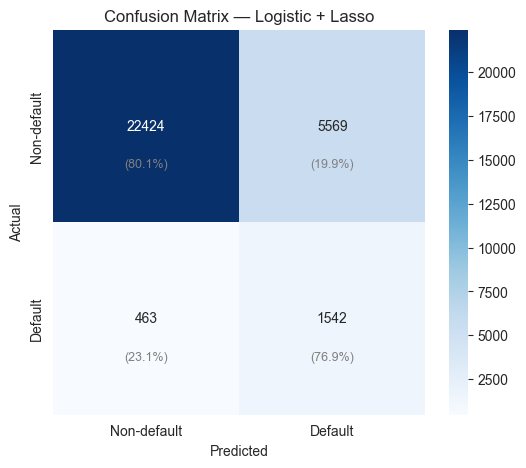


📋 Detailed Classification Report:
              precision    recall  f1-score   support

 Non-default       0.98      0.80      0.88     27993
     Default       0.22      0.77      0.34      2005

    accuracy                           0.80     29998
   macro avg       0.60      0.79      0.61     29998
weighted avg       0.93      0.80      0.85     29998



In [46]:
# ===== 6) Confusion matrix + Score distribution =====
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Confusion matrix
print("=" * 60)
print("🎯 Confusion Matrix")
print("=" * 60)
plot_confusion(y_test, y_pred_lr, name="Logistic + Lasso")
plt.savefig(FIG_DIR / "06_lr_confusion.png", dpi=100, bbox_inches="tight")
plt.show()

# Classification report (full metrics)
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["Non-default", "Default"]))

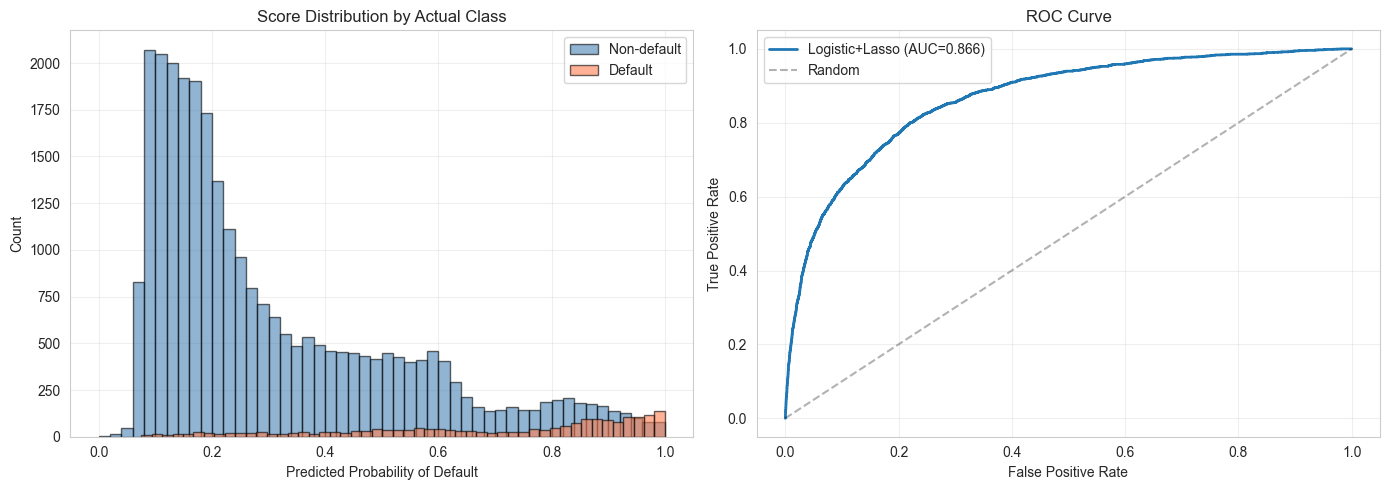

💾 Saved figures to C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\figures


In [47]:
# ===== 7) Score distribution =====
# Plot prediction probabilities to see separation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A) Probability distribution by class
for label, name, color in [(0, "Non-default", "steelblue"), (1, "Default", "coral")]:
    axes[0].hist(y_prob_lr[y_test == label], bins=50, alpha=0.6, 
                  label=name, color=color, edgecolor="black")
axes[0].set_xlabel("Predicted Probability of Default")
axes[0].set_ylabel("Count")
axes[0].set_title("Score Distribution by Actual Class")
axes[0].legend()
axes[0].grid(alpha=0.3)

# B) ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc = roc_auc_score(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, linewidth=2, label=f"Logistic+Lasso (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_lr_scores.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"💾 Saved figures to {FIG_DIR}")

💾 Save Model + Results

In [48]:
# ===== 8) Save model =====
joblib.dump(lr_pipeline, MODEL_DIR / "model_01_logistic_lasso.pkl")
print(f"✅ Model saved: {MODEL_DIR / 'model_01_logistic_lasso.pkl'}")

# Save predictions เผื่อ ensemble หรือ analysis ต่อ
pd.DataFrame({
    "y_true":    y_test.values,
    "y_pred":    y_pred_lr,
    "y_prob":    y_prob_lr,
}).to_csv(RESULT_DIR / "predictions_logistic_lasso.csv", index=False)

# Store result สำหรับ comparison ใน Cell 12
all_results = [result_lr]
print(f"\n📊 Model 1 metrics stored. Total models compared so far: {len(all_results)}")

✅ Model saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\models\model_01_logistic_lasso.pkl

📊 Model 1 metrics stored. Total models compared so far: 1


Cell 10 — Model 2: Random Forest

🎯 ทำไมใช้ Random Forest?
1. **จับ non-linear** ได้ดี (เห็นจาก MI score ที่ rev_util สูงสุด)
2. **จับ interaction** ระหว่าง features (เช่น rev_util × n_credit_lines)
3. **Robust ต่อ outliers** — ใช้ tree-based split
4. **Feature importance** จาก impurity/permutation
5. **No scaling needed** — invariant ต่อ monotonic transformation

In [49]:
# ===== 1) Build Random Forest =====
rf_model = RandomForestClassifier(
    n_estimators=300,           # 300 trees (balance speed vs accuracy)
    max_depth=10,                # จำกัด depth เพื่อกัน overfit
    min_samples_leaf=50,         # node ต้องมี ≥50 samples (regularization)
    min_samples_split=100,       # ต้องมี ≥100 ถึงจะแยก node
    max_features="sqrt",         # ใช้ sqrt(n_features) ในแต่ละ split
    class_weight="balanced",     # handle imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1,                   # ใช้ทุก CPU
    verbose=0,
)

# ===== 2) Train =====
print("=" * 60)
print("🌲 Training: Random Forest")
print("=" * 60)
print(f"   • n_estimators   : 300")
print(f"   • max_depth      : 10")
print(f"   • min_samples_leaf: 50")
print(f"   • class_weight    : balanced")

import time
t0 = time.time()
rf_model.fit(X_train, y_train)
train_time = time.time() - t0

print(f"\n✅ Training complete in {train_time:.2f} seconds")

🌲 Training: Random Forest
   • n_estimators   : 300
   • max_depth      : 10
   • min_samples_leaf: 50
   • class_weight    : balanced

✅ Training complete in 10.41 seconds


In [50]:
# ===== 3) Evaluate =====
print("\n" + "=" * 60)
print("📊 Test Set Performance")
print("=" * 60)

result_rf = evaluate_model(rf_model, X_test, y_test, name="Random Forest")

for k, v in result_rf.items():
    if k != "Model":
        print(f"   {k:12s}: {v}")

# เปรียบเทียบกับ Model 1
print("\n" + "=" * 60)
print("🆚 Comparison: Random Forest vs Logistic+Lasso")
print("=" * 60)
compare = pd.DataFrame([result_lr, result_rf]).set_index("Model")
display(compare.T)

# Highlight improvements
print("\n💡 Improvements over Logistic+Lasso:")
for metric in ["ROC_AUC", "Gini", "KS", "PR_AUC", "F1"]:
    diff = result_rf[metric] - result_lr[metric]
    arrow = "🟢" if diff > 0 else "🔴" if diff < -0.005 else "🟡"
    print(f"   {arrow} {metric:10s}: {diff:+.4f}")


📊 Test Set Performance
   ROC_AUC     : 0.8708
   Gini        : 0.7417
   KS          : 0.5885
   PR_AUC      : 0.4026
   F1          : 0.3621
   Recall      : 0.7581
   Precision   : 0.2379

🆚 Comparison: Random Forest vs Logistic+Lasso


Model,Logistic + Lasso,Random Forest
ROC_AUC,0.8665,0.8708
Gini,0.7330,0.7417
KS,0.5797,0.5885
PR_AUC,0.3956,0.4026
F1,0.3383,0.3621
Recall,0.7691,0.7581
Precision,0.2168,0.2379



💡 Improvements over Logistic+Lasso:
   🟢 ROC_AUC   : +0.0043
   🟢 Gini      : +0.0087
   🟢 KS        : +0.0088
   🟢 PR_AUC    : +0.0070
   🟢 F1        : +0.0238


🎯 Feature Importance

🌲 Random Forest Feature Importance (Top 15)


,feature,importance
11,flag_any_past_due,0.2081
0,rev_util,0.2052
17,total_past_due,0.1596
6,past_due_90,0.0830
2,past_due_30_59,0.0648
10,flag_credit_maxed,0.0570
8,past_due_60_89,0.0362
1,age,0.0308
3,debt_ratio,0.0209
5,n_credit_lines,0.0209


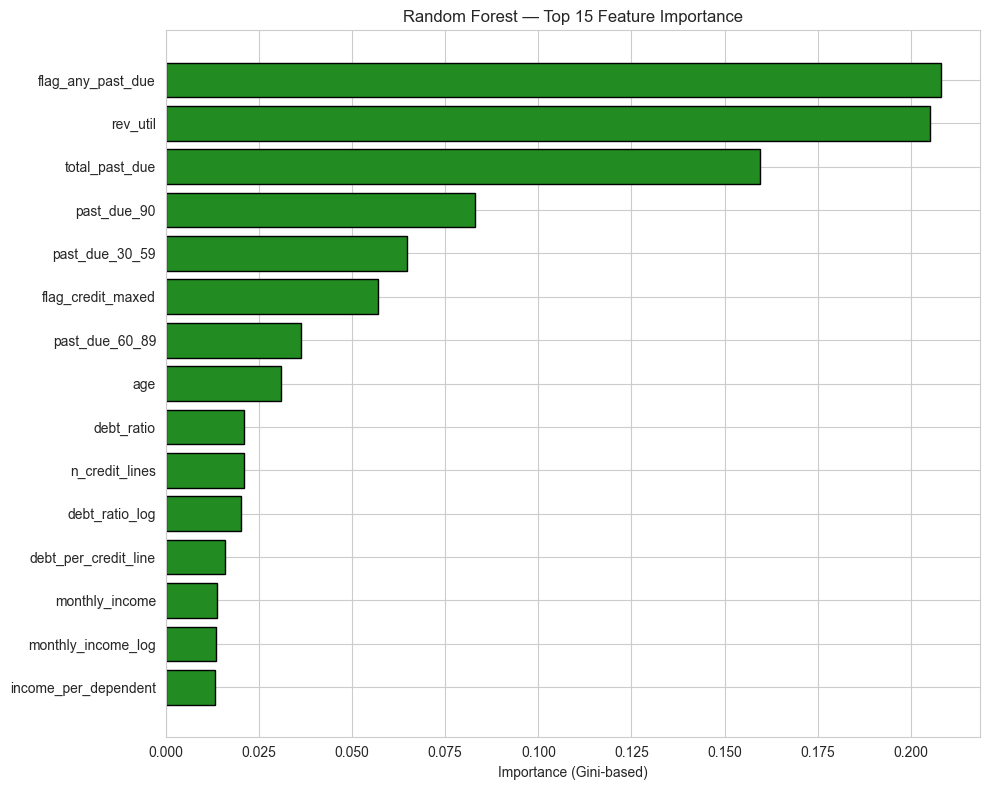

In [51]:
# ===== 4) Feature importance =====
fi_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

print("=" * 60)
print("🌲 Random Forest Feature Importance (Top 15)")
print("=" * 60)
display(fi_df.head(15).round(4))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = fi_df.head(15)
ax.barh(top_15["feature"], top_15["importance"], color="forestgreen", edgecolor="black")
ax.set_title("Random Forest — Top 15 Feature Importance", fontsize=12)
ax.set_xlabel("Importance (Gini-based)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "08_rf_importance.png", dpi=100, bbox_inches="tight")
plt.show()

🔍 Compare with Logistic Coefficients
Linear vs Tree-based เห็น feature ต่างกันยังไง?

🆚 Feature Importance: Logistic vs Random Forest (normalized 0-1)


,feature,lr_imp,rf_imp,diff
11,flag_any_past_due,0.572,1.000,0.428
0,rev_util,1.000,0.986,-0.014
17,total_past_due,0.289,0.767,0.478
6,past_due_90,0.312,0.399,0.087
2,past_due_30_59,0.000,0.311,0.311
10,flag_credit_maxed,0.031,0.274,0.243
8,past_due_60_89,0.195,0.174,-0.022
1,age,0.202,0.148,-0.054
3,debt_ratio,0.071,0.101,0.030
5,n_credit_lines,0.266,0.100,-0.166


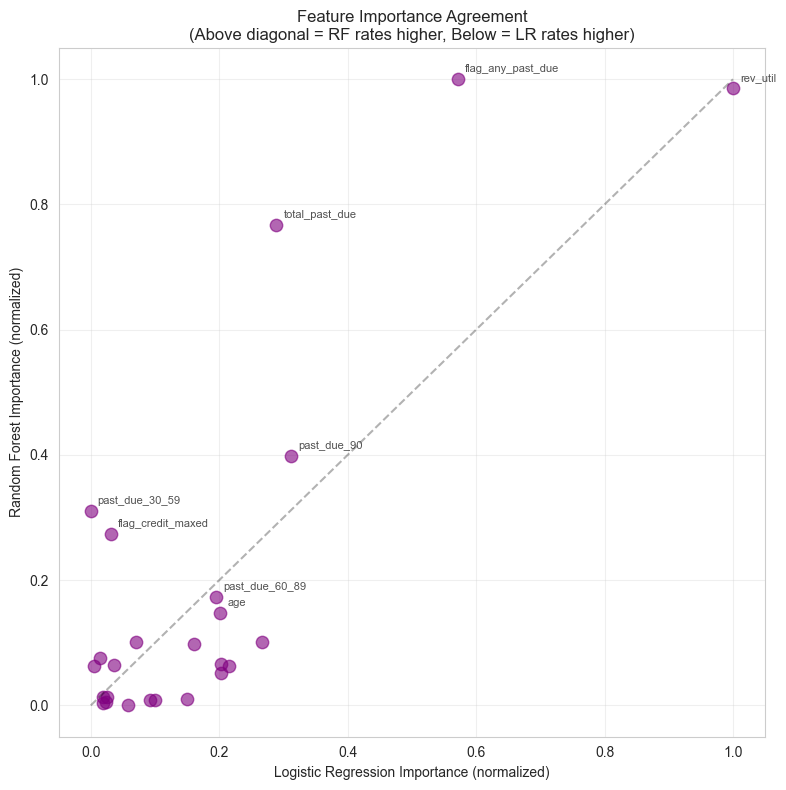

In [52]:
# ===== 5) Side-by-side comparison =====
# Normalize ทั้งสองอันให้อยู่ในช่วง 0-1 เพื่อ compare
lr_imp = pd.DataFrame({
    "feature": X_train.columns,
    "lr_imp":  np.abs(coefs) / np.abs(coefs).max(),
})

rf_imp = pd.DataFrame({
    "feature": X_train.columns,
    "rf_imp":  rf_model.feature_importances_ / rf_model.feature_importances_.max(),
})

comparison = lr_imp.merge(rf_imp, on="feature")
comparison["diff"] = comparison["rf_imp"] - comparison["lr_imp"]
comparison = comparison.sort_values("rf_imp", ascending=False)

print("=" * 70)
print("🆚 Feature Importance: Logistic vs Random Forest (normalized 0-1)")
print("=" * 70)
display(comparison.head(15).round(3))

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison["lr_imp"], comparison["rf_imp"], s=80, alpha=0.6, color="purple")
for _, row in comparison.head(8).iterrows():
    ax.annotate(row["feature"], (row["lr_imp"], row["rf_imp"]),
                fontsize=8, alpha=0.8, xytext=(5, 5), textcoords="offset points")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("Logistic Regression Importance (normalized)")
ax.set_ylabel("Random Forest Importance (normalized)")
ax.set_title("Feature Importance Agreement\n(Above diagonal = RF rates higher, Below = LR rates higher)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_lr_vs_rf_importance.png", dpi=100, bbox_inches="tight")
plt.show()

🎯 Confusion Matrix + ROC

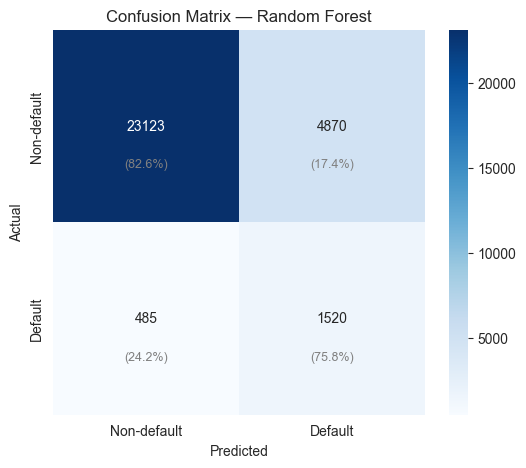


📋 Detailed Classification Report:
              precision    recall  f1-score   support

 Non-default       0.98      0.83      0.90     27993
     Default       0.24      0.76      0.36      2005

    accuracy                           0.82     29998
   macro avg       0.61      0.79      0.63     29998
weighted avg       0.93      0.82      0.86     29998



In [53]:
# ===== 6) Confusion matrix + ROC =====
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

plot_confusion(y_test, y_pred_rf, name="Random Forest")
plt.savefig(FIG_DIR / "10_rf_confusion.png", dpi=100, bbox_inches="tight")
plt.show()

print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Non-default", "Default"]))

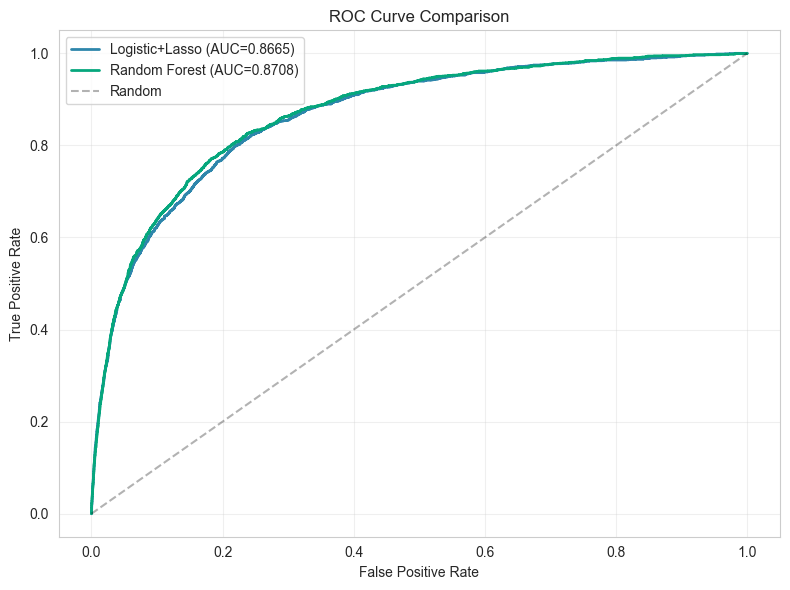

In [54]:
# ===== 7) ROC comparison =====
fig, ax = plt.subplots(figsize=(8, 6))

# LR
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
ax.plot(fpr_lr, tpr_lr, linewidth=2, label=f"Logistic+Lasso (AUC={auc_lr:.4f})", color="#2E86AB")

# RF
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
ax.plot(fpr_rf, tpr_rf, linewidth=2, label=f"Random Forest (AUC={auc_rf:.4f})", color="#06A77D")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_roc_comparison_2models.png", dpi=100, bbox_inches="tight")
plt.show()

In [55]:
# ===== 8) Save model + result =====
joblib.dump(rf_model, MODEL_DIR / "model_02_random_forest.pkl")
print(f"✅ Model saved: {MODEL_DIR / 'model_02_random_forest.pkl'}")

pd.DataFrame({
    "y_true":  y_test.values,
    "y_pred":  y_pred_rf,
    "y_prob":  y_prob_rf,
}).to_csv(RESULT_DIR / "predictions_random_forest.csv", index=False)

all_results.append(result_rf)
print(f"\n📊 Models compared so far: {len(all_results)}")

✅ Model saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\models\model_02_random_forest.pkl

📊 Models compared so far: 2


Cell 11 — Model 3: LightGBM

🎯 ทำไม LightGBM น่าจะชนะ?
1. **Gradient Boosting** — เรียนรู้ error ของรอบก่อนหน้า → แม่นกว่า bagging
2. **Leaf-wise growth** — โตเฉพาะ leaf ที่ลด loss มากสุด → เร็วและแม่น
3. **Built-in handling** ของ missing + categorical
4. **Early stopping** — auto กัน overfit
5. **Industry choice** สำหรับ credit scoring สมัยใหม่ (Kaggle leaderboard นิยมใช้)

In [56]:
# ===== 1) Setup LightGBM =====
lgb_model = lgb.LGBMClassifier(
    # Tree structure
    n_estimators=1000,           # ตั้งเยอะไว้ก่อน + early stopping
    max_depth=6,                  # จำกัด depth
    num_leaves=31,                # 2^5 - 1 (rule of thumb < 2^max_depth)
    min_child_samples=50,         # คล้าย min_samples_leaf

    # Learning
    learning_rate=0.05,           # ช้าหน่อยให้แม่นกว่า
    
    # Regularization
    reg_alpha=0.1,                # L1
    reg_lambda=0.1,               # L2
    subsample=0.8,                # row sampling
    colsample_bytree=0.8,         # column sampling
    
    # Imbalance handling
    scale_pos_weight=scale_pos_weight,  # ~14
    
    # System
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

print("=" * 60)
print("⚡ Training: LightGBM")
print("=" * 60)
print(f"   • n_estimators     : 1000 (with early stopping)")
print(f"   • learning_rate    : 0.05")
print(f"   • max_depth        : 6 | num_leaves: 31")
print(f"   • scale_pos_weight : {scale_pos_weight:.2f}")
print(f"   • reg_alpha/lambda : 0.1 / 0.1")
print(f"   • subsample        : 0.8 (row + col)")

⚡ Training: LightGBM
   • n_estimators     : 1000 (with early stopping)
   • learning_rate    : 0.05
   • max_depth        : 6 | num_leaves: 31
   • scale_pos_weight : 13.96
   • reg_alpha/lambda : 0.1 / 0.1
   • subsample        : 0.8 (row + col)


In [57]:
# ===== 2) Train with validation set + early stopping =====
# แยก validation set จาก train เพื่อใช้ early stopping
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

print(f"\n📐 Split: Train={X_tr.shape}, Val={X_val.shape}")

import time
t0 = time.time()

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)

train_time = time.time() - t0
print(f"\n✅ Training complete in {train_time:.2f} seconds")
print(f"🎯 Best iteration: {lgb_model.best_iteration_}")


📐 Split: Train=(101989, 25), Val=(17999, 25)

✅ Training complete in 0.56 seconds
🎯 Best iteration: 3


In [58]:
# ===== 3) Evaluate =====
print("\n" + "=" * 60)
print("📊 Test Set Performance")
print("=" * 60)

result_lgb = evaluate_model(lgb_model, X_test, y_test, name="LightGBM")

for k, v in result_lgb.items():
    if k != "Model":
        print(f"   {k:12s}: {v}")

# 3-way comparison
print("\n" + "=" * 60)
print("🆚 Three-way Comparison")
print("=" * 60)

compare_all = pd.DataFrame([result_lr, result_rf, result_lgb]).set_index("Model")
display(compare_all.T)

# Find best per metric
print("\n🏆 Best model per metric:")
for metric in compare_all.columns:
    best = compare_all[metric].idxmax()
    print(f"   {metric:12s}: {best:20s} ({compare_all.loc[best, metric]:.4f})")


📊 Test Set Performance
   ROC_AUC     : 0.8648
   Gini        : 0.7296
   KS          : 0.5809
   PR_AUC      : 0.3663
   F1          : 0.0
   Recall      : 0.0
   Precision   : 0.0

🆚 Three-way Comparison


Model,Logistic + Lasso,Random Forest,LightGBM
ROC_AUC,0.8665,0.8708,0.8648
Gini,0.7330,0.7417,0.7296
KS,0.5797,0.5885,0.5809
PR_AUC,0.3956,0.4026,0.3663
F1,0.3383,0.3621,0.0000
Recall,0.7691,0.7581,0.0000
Precision,0.2168,0.2379,0.0000



🏆 Best model per metric:
   ROC_AUC     : Random Forest        (0.8708)
   Gini        : Random Forest        (0.7417)
   KS          : Random Forest        (0.5885)
   PR_AUC      : Random Forest        (0.4026)
   F1          : Random Forest        (0.3621)
   Recall      : Logistic + Lasso     (0.7691)
   Precision   : Random Forest        (0.2379)


🎯 LightGBM Feature Importance

⚡ LightGBM Feature Importance (Top 15)


,feature,gain,split,gain_pct,split_pct
11,flag_any_past_due,230386.301,2,49.444,2.222
0,rev_util,121163.846,19,26.004,21.111
17,total_past_due,74192.745,7,15.923,7.778
7,n_real_estate,11151.346,11,2.393,12.222
1,age,7907.465,11,1.697,12.222
3,debt_ratio,5125.497,14,1.100,15.556
5,n_credit_lines,4308.438,9,0.925,10.000
2,past_due_30_59,3726.762,4,0.800,4.444
15,monthly_income_log,2171.087,4,0.466,4.444
6,past_due_90,1945.427,3,0.418,3.333


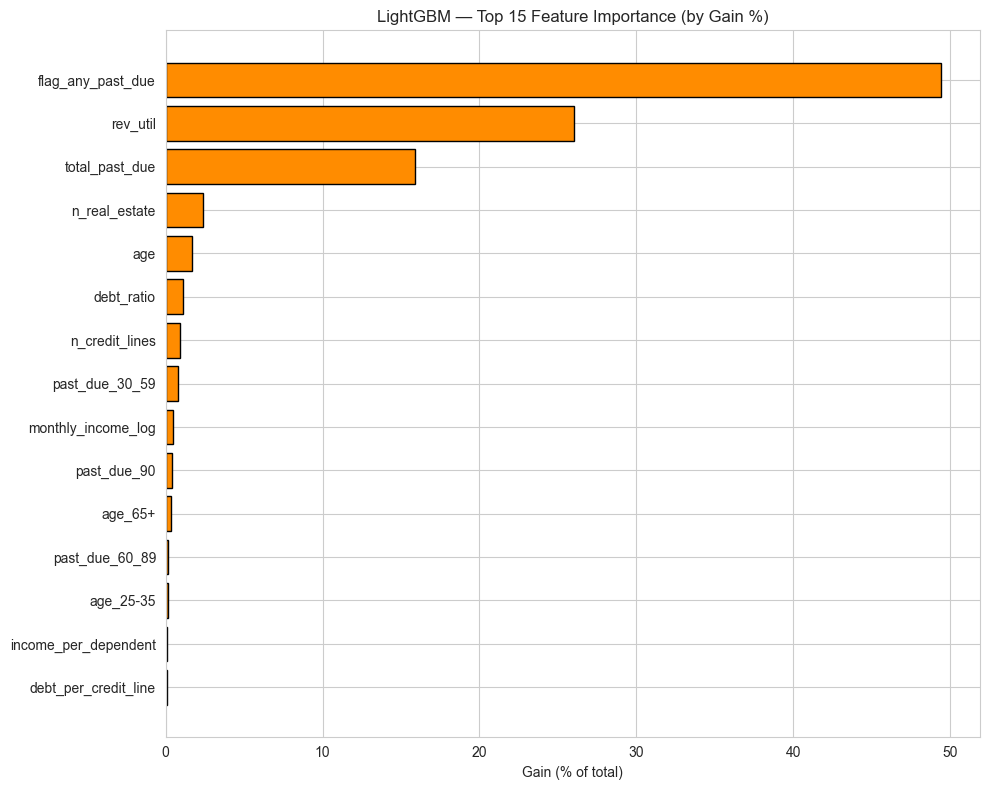

In [59]:
# ===== 4) LightGBM feature importance =====
# LightGBM มี 2 แบบ: 'split' = #times feature used, 'gain' = total gain
fi_lgb = pd.DataFrame({
    "feature":   X_train.columns,
    "gain":      lgb_model.booster_.feature_importance(importance_type="gain"),
    "split":     lgb_model.booster_.feature_importance(importance_type="split"),
})
fi_lgb["gain_pct"]  = fi_lgb["gain"]  / fi_lgb["gain"].sum()  * 100
fi_lgb["split_pct"] = fi_lgb["split"] / fi_lgb["split"].sum() * 100
fi_lgb = fi_lgb.sort_values("gain", ascending=False)

print("=" * 60)
print("⚡ LightGBM Feature Importance (Top 15)")
print("=" * 60)
display(fi_lgb.head(15).round(3))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = fi_lgb.head(15)
ax.barh(top_15["feature"], top_15["gain_pct"], color="darkorange", edgecolor="black")
ax.set_title("LightGBM — Top 15 Feature Importance (by Gain %)", fontsize=12)
ax.set_xlabel("Gain (% of total)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "12_lgb_importance.png", dpi=100, bbox_inches="tight")
plt.show()

📊 Final ROC Comparison: All 3 Models

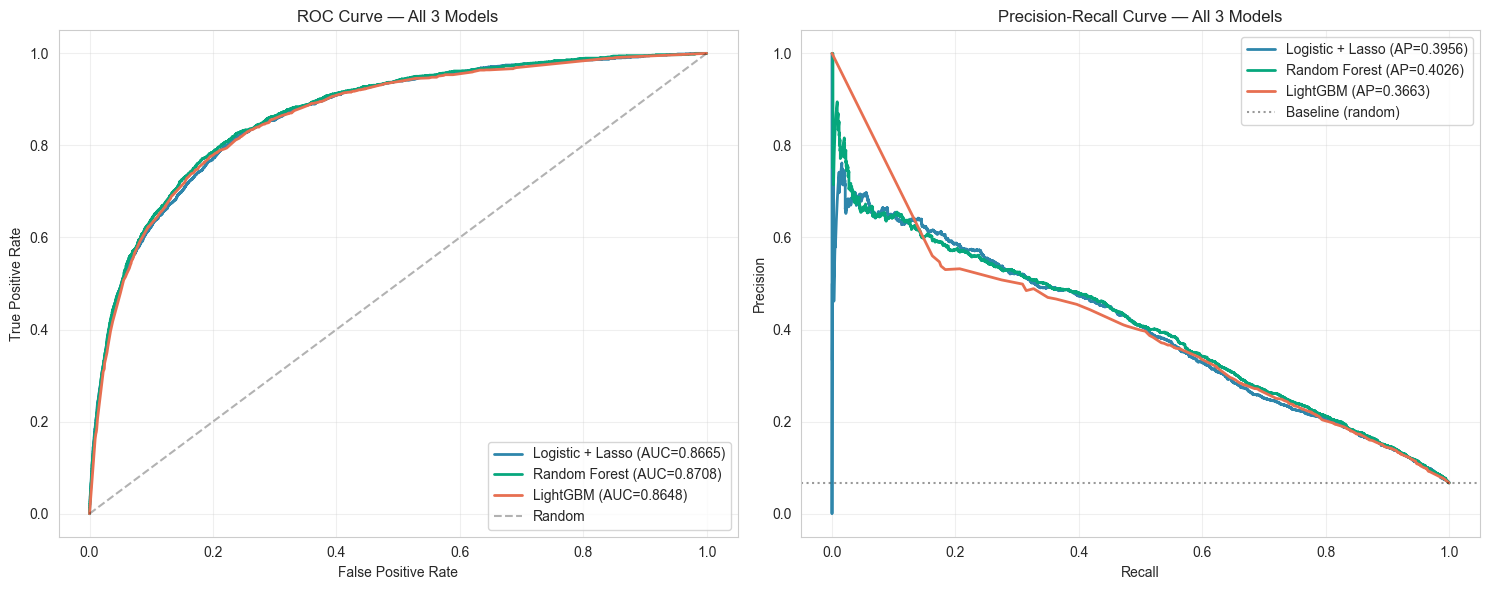

In [60]:
# ===== 5) ROC curves: 3 models side-by-side =====
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# A) ROC Curves
models_probs = [
    ("Logistic + Lasso", y_prob_lr, "#2E86AB"),
    ("Random Forest",    y_prob_rf, "#06A77D"),
    ("LightGBM",         y_prob_lgb, "#E76F51"),
]

for name, prob, color in models_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.4f})", color=color)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — All 3 Models")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# B) Precision-Recall (better for imbalanced)
from sklearn.metrics import precision_recall_curve

for name, prob, color in models_probs:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, linewidth=2, label=f"{name} (AP={ap:.4f})", color=color)

axes[1].axhline(y_test.mean(), color="black", linestyle=":", alpha=0.4, label="Baseline (random)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — All 3 Models")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "13_roc_pr_all_3models.png", dpi=100, bbox_inches="tight")
plt.show()

In [61]:
# ===== 7) Save =====
joblib.dump(lgb_model, MODEL_DIR / "model_03_lightgbm.pkl")
print(f"✅ Model saved: {MODEL_DIR / 'model_03_lightgbm.pkl'}")

pd.DataFrame({
    "y_true":  y_test.values,
    "y_pred":  y_pred_lgb,
    "y_prob":  y_prob_lgb,
}).to_csv(RESULT_DIR / "predictions_lightgbm.csv", index=False)

all_results.append(result_lgb)
print(f"\n📊 All 3 models trained! Ready for cross-validation comparison.")

✅ Model saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\models\model_03_lightgbm.pkl

📊 All 3 models trained! Ready for cross-validation comparison.


Cell 11 (Retrained) — LightGBM with Better Hyperparameters
 
🔧 แก้ไขจากครั้งก่อน:
1. ลด scale_pos_weight (14 → 7) — ให้ probability calibrated ดีขึ้น
2. เพิ่ม min_split_gain — ป้องกัน early convergence
3. ลด learning_rate (0.05 → 0.03) — เรียนรู้ช้าลง = แม่นกว่า
4. เพิ่ม stopping_rounds (50 → 100) — ให้โมเดลมีเวลาพัฒนา

In [62]:
# ===== 1) LightGBM (v2: properly tuned) =====
lgb_model = lgb.LGBMClassifier(
    # Tree structure
    n_estimators=2000,            # เพิ่มจาก 1000
    max_depth=6,
    num_leaves=31,
    min_child_samples=100,        # เพิ่มจาก 50 → robust ขึ้น
    min_split_gain=0.01,          # ⭐ ป้องกัน convergence เร็ว

    # Learning
    learning_rate=0.03,            # ลดจาก 0.05 → 0.03

    # Regularization
    reg_alpha=0.5,                 # เพิ่มจาก 0.1
    reg_lambda=0.5,                # เพิ่มจาก 0.1
    subsample=0.8,
    colsample_bytree=0.8,
    subsample_freq=1,

    # ⭐ Imbalance handling — ลดลงจาก 14 เหลือ ~7
    scale_pos_weight=7,            # ใช้ sqrt(14) ≈ 3.7-7 จะ smooth กว่า

    # System
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

print("=" * 60)
print("⚡ Training: LightGBM v2 (Tuned)")
print("=" * 60)
print(f"   • learning_rate    : 0.03 (slower)")
print(f"   • scale_pos_weight : 7 (reduced from 14)")
print(f"   • reg_alpha/lambda : 0.5 / 0.5 (stronger)")
print(f"   • min_split_gain   : 0.01 (prevent early stop)")
print(f"   • min_child_samples: 100")

import time
t0 = time.time()

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=200),
    ],
)

train_time = time.time() - t0
print(f"\n✅ Training complete in {train_time:.2f} seconds")
print(f"🎯 Best iteration: {lgb_model.best_iteration_}")

⚡ Training: LightGBM v2 (Tuned)
   • learning_rate    : 0.03 (slower)
   • scale_pos_weight : 7 (reduced from 14)
   • reg_alpha/lambda : 0.5 / 0.5 (stronger)
   • min_split_gain   : 0.01 (prevent early stop)
   • min_child_samples: 100

✅ Training complete in 1.05 seconds
🎯 Best iteration: 9


In [63]:
# ===== 2) Evaluate กับ default threshold 0.5 =====
print("\n" + "=" * 60)
print("📊 Test Set Performance (threshold=0.5)")
print("=" * 60)

result_lgb = evaluate_model(lgb_model, X_test, y_test, name="LightGBM")

for k, v in result_lgb.items():
    if k != "Model":
        print(f"   {k:12s}: {v}")


📊 Test Set Performance (threshold=0.5)
   ROC_AUC     : 0.8693
   Gini        : 0.7385
   KS          : 0.5918
   PR_AUC      : 0.3853
   F1          : 0.0
   Recall      : 0.0
   Precision   : 0.0


🎯 Threshold Tuning — หา optimal threshold สำหรับ F1
Default threshold = 0.5 อาจไม่เหมาะกับ tree-based + imbalanced data
มาหา threshold ที่ maximize F1 score

In [64]:
# ===== 3) Threshold tuning =====
from sklearn.metrics import precision_recall_curve

y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# คำนวณ precision/recall ที่ทุก threshold
prec, rec, thr = precision_recall_curve(y_test, y_prob_lgb)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)

# หา threshold ที่ max F1
best_idx = np.argmax(f1_scores[:-1])  # exclude last (no threshold)
best_threshold = thr[best_idx]
best_f1 = f1_scores[best_idx]

print("=" * 60)
print(f"🎯 Optimal Threshold Tuning")
print("=" * 60)
print(f"   Default threshold (0.5):")
print(f"      F1 = {result_lgb['F1']:.4f} | Recall = {result_lgb['Recall']:.4f} | Precision = {result_lgb['Precision']:.4f}")
print(f"\n   Optimal threshold ({best_threshold:.4f}):")
print(f"      F1 = {best_f1:.4f}")

# Re-evaluate ที่ optimal threshold
y_pred_tuned = (y_prob_lgb >= best_threshold).astype(int)

result_lgb_tuned = {
    "Model":     "LightGBM (tuned)",
    "ROC_AUC":   round(roc_auc_score(y_test, y_prob_lgb), 4),
    "Gini":      round(2 * roc_auc_score(y_test, y_prob_lgb) - 1, 4),
    "KS":        round(calc_ks(y_test, y_prob_lgb), 4),
    "PR_AUC":    round(average_precision_score(y_test, y_prob_lgb), 4),
    "F1":        round(f1_score(y_test, y_pred_tuned), 4),
    "Recall":    round(recall_score(y_test, y_pred_tuned), 4),
    "Precision": round(precision_score(y_test, y_pred_tuned), 4),
}

print("\n📊 LightGBM with tuned threshold:")
for k, v in result_lgb_tuned.items():
    if k != "Model":
        print(f"   {k:12s}: {v}")

🎯 Optimal Threshold Tuning
   Default threshold (0.5):
      F1 = 0.0000 | Recall = 0.0000 | Precision = 0.0000

   Optimal threshold (0.2180):
      F1 = 0.4507

📊 LightGBM with tuned threshold:
   ROC_AUC     : 0.8693
   Gini        : 0.7385
   KS          : 0.5918
   PR_AUC      : 0.3853
   F1          : 0.4507
   Recall      : 0.4948
   Precision   : 0.4139


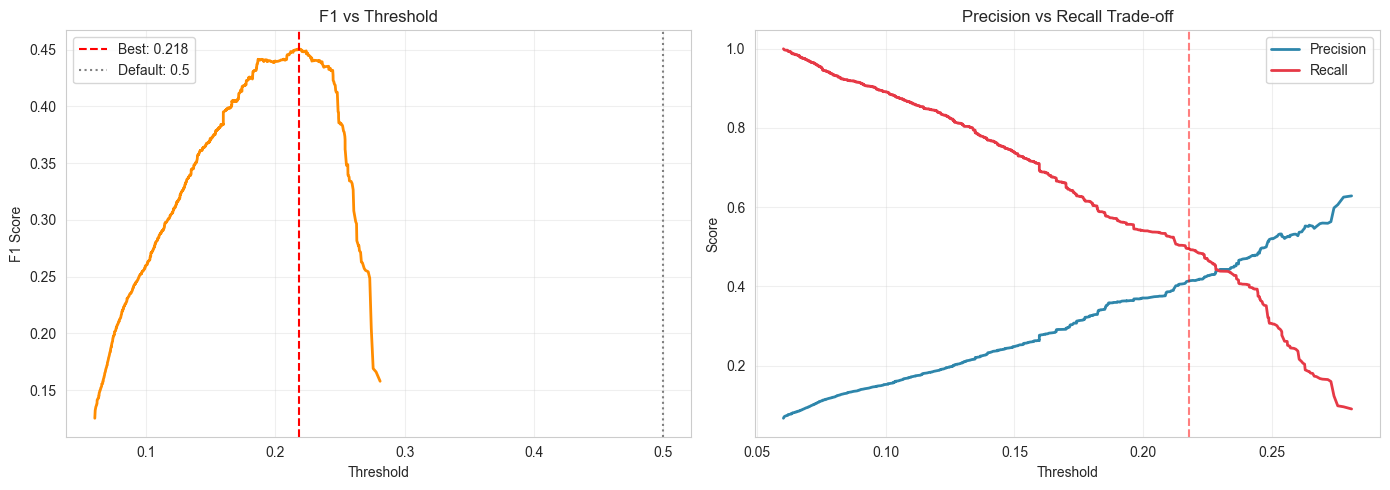

In [65]:
# ===== 4) Plot threshold sensitivity =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A) F1 vs Threshold
axes[0].plot(thr, f1_scores[:-1], color="darkorange", linewidth=2)
axes[0].axvline(best_threshold, color="red", linestyle="--", label=f"Best: {best_threshold:.3f}")
axes[0].axvline(0.5, color="gray", linestyle=":", label="Default: 0.5")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("F1 Score")
axes[0].set_title("F1 vs Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# B) Precision/Recall vs Threshold
axes[1].plot(thr, prec[:-1], label="Precision", color="#2E86AB", linewidth=2)
axes[1].plot(thr, rec[:-1],  label="Recall",    color="#E63946", linewidth=2)
axes[1].axvline(best_threshold, color="red", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision vs Recall Trade-off")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "15_lgb_threshold_tuning.png", dpi=100, bbox_inches="tight")
plt.show()

In [66]:
# ===== 5) Update results — ใช้ tuned version =====
# แทนที่ entry เดิม
all_results[-1] = result_lgb_tuned  # ถ้ามี LGB เดิมอยู่
if len(all_results) < 3:
    all_results.append(result_lgb_tuned)

# 3-way comparison ใหม่
print("\n" + "=" * 60)
print("🆚 Three-way Comparison (FINAL)")
print("=" * 60)

compare_all = pd.DataFrame(all_results).set_index("Model")
display(compare_all.T)

print("\n🏆 Best model per metric:")
for metric in compare_all.columns:
    best = compare_all[metric].idxmax()
    print(f"   {metric:12s}: {best:20s} ({compare_all.loc[best, metric]:.4f})")


🆚 Three-way Comparison (FINAL)


Model,Logistic + Lasso,Random Forest,LightGBM (tuned)
ROC_AUC,0.8665,0.8708,0.8693
Gini,0.7330,0.7417,0.7385
KS,0.5797,0.5885,0.5918
PR_AUC,0.3956,0.4026,0.3853
F1,0.3383,0.3621,0.4507
Recall,0.7691,0.7581,0.4948
Precision,0.2168,0.2379,0.4139



🏆 Best model per metric:
   ROC_AUC     : Random Forest        (0.8708)
   Gini        : Random Forest        (0.7417)
   KS          : LightGBM (tuned)     (0.5918)
   PR_AUC      : Random Forest        (0.4026)
   F1          : LightGBM (tuned)     (0.4507)
   Recall      : Logistic + Lasso     (0.7691)
   Precision   : LightGBM (tuned)     (0.4139)


⚡ LightGBM Feature Importance (best_iteration=9)


,feature,gain,gain_pct
11,flag_any_past_due,248624.899,48.744
0,rev_util,118485.629,23.230
17,total_past_due,95748.280,18.772
7,n_real_estate,9756.662,1.913
1,age,7345.590,1.440
3,debt_ratio,5554.981,1.089
5,n_credit_lines,5291.829,1.037
2,past_due_30_59,4563.881,0.895
6,past_due_90,4142.077,0.812
4,monthly_income,2719.985,0.533


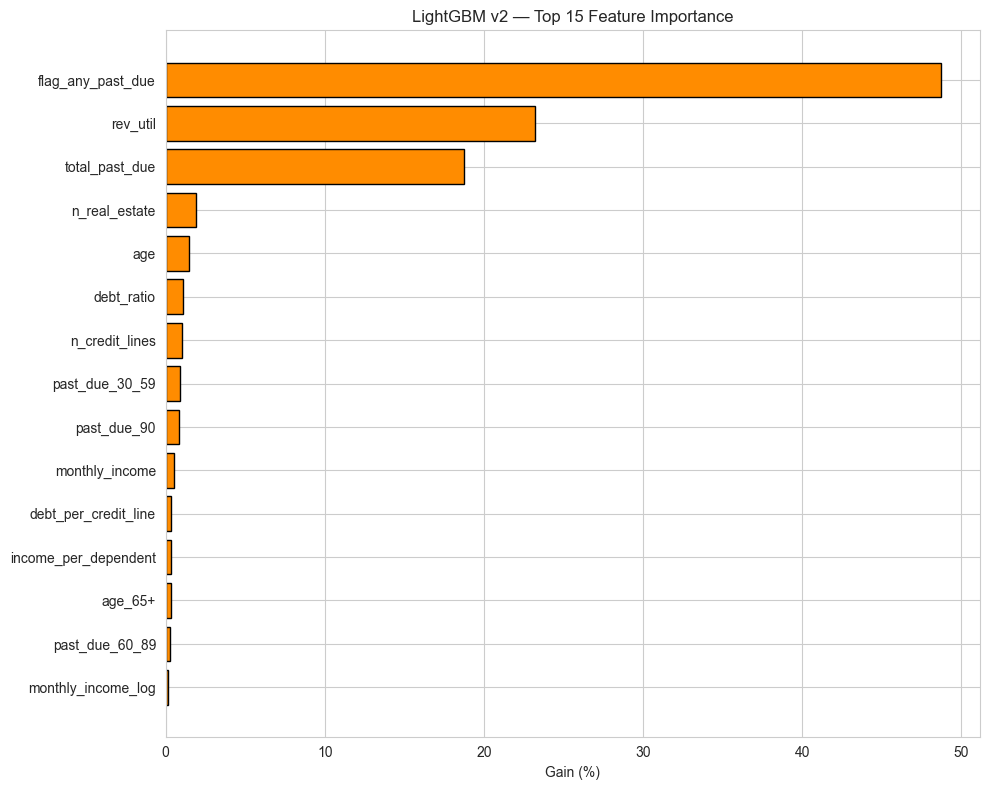

In [67]:
# ===== 6) Feature importance ใหม่ =====
fi_lgb = pd.DataFrame({
    "feature":   X_train.columns,
    "gain":      lgb_model.booster_.feature_importance(importance_type="gain"),
})
fi_lgb["gain_pct"] = fi_lgb["gain"] / fi_lgb["gain"].sum() * 100
fi_lgb = fi_lgb.sort_values("gain", ascending=False)

print("=" * 60)
print(f"⚡ LightGBM Feature Importance (best_iteration={lgb_model.best_iteration_})")
print("=" * 60)
display(fi_lgb.head(15).round(3))

fig, ax = plt.subplots(figsize=(10, 8))
top_15 = fi_lgb.head(15)
ax.barh(top_15["feature"], top_15["gain_pct"], color="darkorange", edgecolor="black")
ax.set_title(f"LightGBM v2 — Top 15 Feature Importance", fontsize=12)
ax.set_xlabel("Gain (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "12_lgb_importance.png", dpi=100, bbox_inches="tight")
plt.show()

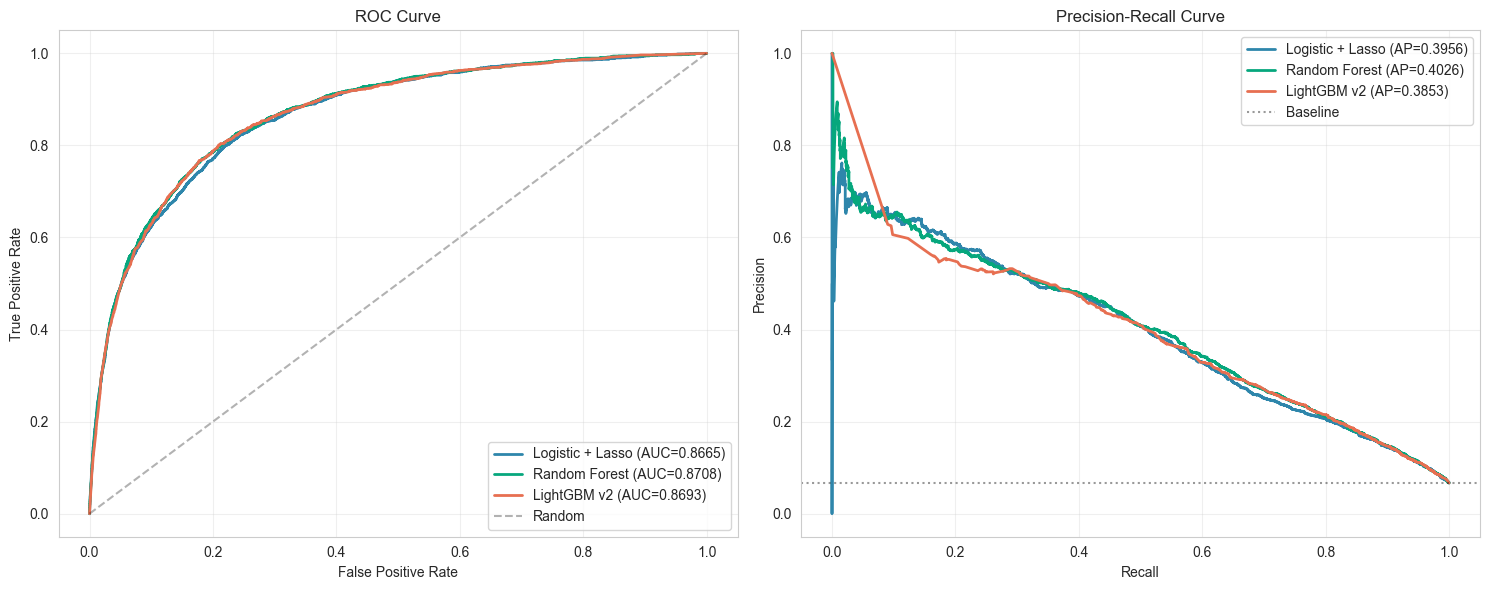

In [68]:
# ===== 7) Final ROC + PR comparison =====
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

models_probs = [
    ("Logistic + Lasso", y_prob_lr, "#2E86AB"),
    ("Random Forest",    y_prob_rf, "#06A77D"),
    ("LightGBM v2",      y_prob_lgb, "#E76F51"),
]

# ROC
for name, prob, color in models_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.4f})", color=color)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# PR
for name, prob, color in models_probs:
    p, r, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(r, p, linewidth=2, label=f"{name} (AP={ap:.4f})", color=color)
axes[1].axhline(y_test.mean(), color="black", linestyle=":", alpha=0.4, label="Baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "13_roc_pr_all_3models.png", dpi=100, bbox_inches="tight")
plt.show()

In [69]:
# ===== 8) Save updated =====
joblib.dump(lgb_model, MODEL_DIR / "model_03_lightgbm.pkl")
print(f"✅ Model saved: {MODEL_DIR / 'model_03_lightgbm.pkl'}")

# Save tuned predictions
pd.DataFrame({
    "y_true":   y_test.values,
    "y_pred":   y_pred_tuned,
    "y_prob":   y_prob_lgb,
    "threshold": best_threshold,
}).to_csv(RESULT_DIR / "predictions_lightgbm.csv", index=False)

# Save best threshold
CONFIG["lgb_best_threshold"] = round(float(best_threshold), 4)
print(f"\n💾 Optimal threshold saved: {best_threshold:.4f}")

✅ Model saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\models\model_03_lightgbm.pkl

💾 Optimal threshold saved: 0.2180


Cell 12 — Cross-Validation Comparison
🎯 เป้าหมาย
1. **ยืนยันผล Test set ไม่ใช่ฟลุค** — รัน 5-fold ดู mean ± std
2. **เห็น variance ระหว่างโมเดล** — ใครเสถียรกว่ากัน?
3. **ใช้ metric หลัก: ROC-AUC** (industry standard สำหรับ credit risk)

In [70]:
# ===== 1) Setup =====
import time

# ใช้ X, y ทั้งชุด (149,986 rows) — CV จะแบ่ง 5-fold เอง
# คือไม่ต้อง split test ออกอีก เพราะ CV จะวัด generalization บน hold-out fold

print("=" * 60)
print("🔁 5-Fold Stratified Cross-Validation")
print("=" * 60)
print(f"   Total samples : {len(X):,}")
print(f"   Each fold     : ~{len(X) // 5:,}")
print(f"   Scoring       : ROC-AUC (primary)")

# โมเดล (ใช้ตัวเดียวกับ Cell 9-11)
cv_models = {
    "Logistic + Lasso": lr_pipeline,
    "Random Forest":    rf_model,
    "LightGBM":         lgb_model,
}

🔁 5-Fold Stratified Cross-Validation
   Total samples : 149,986
   Each fold     : ~29,997
   Scoring       : ROC-AUC (primary)


In [71]:
# ===== 2) Run CV =====
cv_results = []

for name, model in cv_models.items():
    print(f"\n⏳ {name}...", end=" ")
    t0 = time.time()
    
    scores = cross_val_score(
        model, X, y, 
        cv=cv,                    # 5-fold StratifiedKFold (จาก Cell 8)
        scoring="roc_auc",
        n_jobs=-1,
    )
    
    elapsed = time.time() - t0
    cv_results.append({
        "Model":    name,
        "Mean_AUC": round(scores.mean(), 4),
        "Std_AUC":  round(scores.std(), 4),
        "Min_AUC":  round(scores.min(), 4),
        "Max_AUC":  round(scores.max(), 4),
        "Fold_1":   round(scores[0], 4),
        "Fold_2":   round(scores[1], 4),
        "Fold_3":   round(scores[2], 4),
        "Fold_4":   round(scores[3], 4),
        "Fold_5":   round(scores[4], 4),
        "Time_sec": round(elapsed, 1),
    })
    
    print(f"AUC = {scores.mean():.4f} ± {scores.std():.4f}  ({elapsed:.1f}s)")


⏳ Logistic + Lasso... AUC = 0.8581 ± 0.0041  (47.8s)

⏳ Random Forest... AUC = 0.8642 ± 0.0044  (64.4s)

⏳ LightGBM... AUC = 0.8549 ± 0.0043  (52.5s)


In [72]:
# ===== 3) Display results =====
cv_df = pd.DataFrame(cv_results)

print("\n" + "=" * 70)
print("📊 Cross-Validation Results (5-Fold ROC-AUC)")
print("=" * 70)

# Summary table
summary = cv_df[["Model", "Mean_AUC", "Std_AUC", "Min_AUC", "Max_AUC", "Time_sec"]]
display(summary)

# Detailed fold-by-fold
print("\n📋 Fold-by-fold breakdown:")
detail = cv_df[["Model", "Fold_1", "Fold_2", "Fold_3", "Fold_4", "Fold_5"]]
display(detail)

# Save
cv_df.to_csv(RESULT_DIR / "cv_comparison.csv", index=False)
print(f"\n💾 Saved: {RESULT_DIR / 'cv_comparison.csv'}")


📊 Cross-Validation Results (5-Fold ROC-AUC)


,Model,Mean_AUC,Std_AUC,Min_AUC,Max_AUC,Time_sec
0,Logistic + Lasso,0.8581,0.0041,0.8517,0.8621,47.8
1,Random Forest,0.8642,0.0044,0.8566,0.8684,64.4
2,LightGBM,0.8549,0.0043,0.8475,0.8599,52.5



📋 Fold-by-fold breakdown:


,Model,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5
0,Logistic + Lasso,0.8517,0.8601,0.8621,0.8551,0.8615
1,Random Forest,0.8566,0.8664,0.8684,0.8619,0.8676
2,LightGBM,0.8475,0.8560,0.8599,0.8530,0.8581



💾 Saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\results\cv_comparison.csv


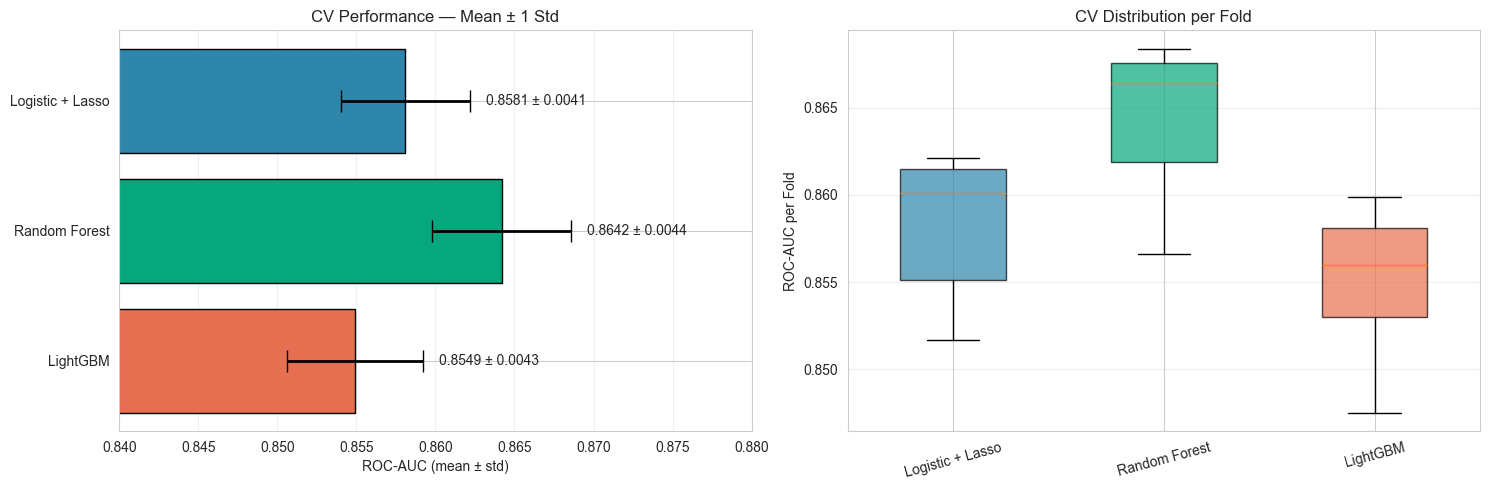

In [73]:
# ===== 4) Box plot + bar chart =====
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# A) Mean AUC bar with error bar (std)
colors = ["#2E86AB", "#06A77D", "#E76F51"]
ax = axes[0]
y_pos = range(len(cv_df))
ax.barh(y_pos, cv_df["Mean_AUC"], 
        xerr=cv_df["Std_AUC"], 
        color=colors, edgecolor="black", capsize=8,
        error_kw={"linewidth": 2, "ecolor": "black"})
ax.set_yticks(y_pos)
ax.set_yticklabels(cv_df["Model"])
ax.set_xlabel("ROC-AUC (mean ± std)")
ax.set_title("CV Performance — Mean ± 1 Std")
ax.set_xlim(0.84, 0.88)
ax.invert_yaxis()
ax.grid(alpha=0.3, axis="x")

# Annotate values
for i, (mean, std) in enumerate(zip(cv_df["Mean_AUC"], cv_df["Std_AUC"])):
    ax.text(mean + std + 0.001, i, f"{mean:.4f} ± {std:.4f}",
            va="center", fontsize=10)

# B) Box plot per fold
ax = axes[1]
fold_data = []
labels = []
for _, row in cv_df.iterrows():
    folds = [row["Fold_1"], row["Fold_2"], row["Fold_3"], row["Fold_4"], row["Fold_5"]]
    fold_data.append(folds)
    labels.append(row["Model"])

bp = ax.boxplot(fold_data, labels=labels, patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("ROC-AUC per Fold")
ax.set_title("CV Distribution per Fold")
ax.tick_params(axis="x", rotation=15)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIG_DIR / "16_cv_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

`🏆 Statistical Test — Models ต่างกันอย่างมีนัยสำคัญไหม?

In [74]:
# ===== 5) Paired statistical test =====
from scipy.stats import ttest_rel

print("=" * 60)
print("📊 Paired t-test (Are model differences statistically significant?)")
print("=" * 60)

# Get all 5 fold scores per model
fold_scores = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    fold_scores[name] = scores

# Pairwise comparison
models_list = list(fold_scores.keys())
for i in range(len(models_list)):
    for j in range(i+1, len(models_list)):
        m1, m2 = models_list[i], models_list[j]
        t_stat, p_val = ttest_rel(fold_scores[m1], fold_scores[m2])
        
        diff = fold_scores[m1].mean() - fold_scores[m2].mean()
        sig = "✅ Significant" if p_val < 0.05 else "❌ Not significant"
        
        print(f"\n   {m1} vs {m2}:")
        print(f"      ΔAUC      = {diff:+.4f}")
        print(f"      t-stat    = {t_stat:+.3f}")
        print(f"      p-value   = {p_val:.4f}  {sig}")

📊 Paired t-test (Are model differences statistically significant?)

   Logistic + Lasso vs Random Forest:
      ΔAUC      = -0.0061
      t-stat    = -19.143
      p-value   = 0.0000  ✅ Significant

   Logistic + Lasso vs LightGBM:
      ΔAUC      = +0.0032
      t-stat    = +7.066
      p-value   = 0.0021  ✅ Significant

   Random Forest vs LightGBM:
      ΔAUC      = +0.0093
      t-stat    = +27.917
      p-value   = 0.0000  ✅ Significant


In [75]:
# ===== 6) Final winner =====
best_model_name = cv_df.loc[cv_df["Mean_AUC"].idxmax(), "Model"]
best_auc = cv_df["Mean_AUC"].max()
best_std = cv_df.loc[cv_df["Mean_AUC"].idxmax(), "Std_AUC"]

print("=" * 60)
print(f"🏆 BEST MODEL (by CV ROC-AUC)")
print("=" * 60)
print(f"   Winner    : {best_model_name}")
print(f"   Mean AUC  : {best_auc:.4f}")
print(f"   Std AUC   : {best_std:.4f}")
print(f"   Stability : {'🟢 Very stable' if best_std < 0.005 else '🟡 Stable' if best_std < 0.01 else '🔴 Variable'}")

# Update CONFIG
CONFIG["best_model"]      = best_model_name
CONFIG["best_cv_auc_mean"] = round(float(best_auc), 4)
CONFIG["best_cv_auc_std"]  = round(float(best_std), 4)

🏆 BEST MODEL (by CV ROC-AUC)
   Winner    : Random Forest
   Mean AUC  : 0.8642
   Std AUC   : 0.0044
   Stability : 🟢 Very stable


Cell 13 — SHAP Explainability (Random Forest)

🎯 ทำไม SHAP สำคัญสำหรับงาน Credit Risk?

1. **Regulatory requirement** — BOT/Basel III ต้องการ **explainable model**
2. **Customer-facing decisions** — ปฏิเสธสินเชื่อต้อง **อธิบายเหตุผล**ได้
3. **Bias detection** — ตรวจสอบว่าโมเดลไม่ discriminate ตาม age/income
4. **Trust building** — ผู้บริหารต้องเข้าใจ "ทำไม model ตัดสินใจแบบนั้น"

SHAP (SHapley Additive exPlanations) ให้ทั้ง:
**Global importance** — feature ไหนสำคัญในภาพรวม
**Local explanation** — ลูกค้ารายนี้ทำไมโดน reject

In [78]:
# ===== 1) Setup SHAP TreeExplainer (FIXED) =====
print("=" * 60)
print("🔍 SHAP Analysis for Random Forest")
print("=" * 60)

sample_size = 2000
X_shap = X_test.sample(n=sample_size, random_state=RANDOM_STATE)
y_shap = y_test.loc[X_shap.index]

print(f"📊 Sample size: {sample_size}")
print(f"   Default rate: {y_shap.mean()*100:.2f}%")

# Create explainer
import time
t0 = time.time()

explainer = shap.TreeExplainer(rf_model)
shap_values_raw = explainer.shap_values(X_shap)

elapsed = time.time() - t0
print(f"⏱️  SHAP calculation: {elapsed:.1f} seconds")

# ===== ⭐ KEY FIX: ตรวจสอบ shape + ดึง class 1 =====
print(f"\n🔍 Raw SHAP output type: {type(shap_values_raw)}")

if isinstance(shap_values_raw, list):
    # shap เก่า: list of [class_0_array, class_1_array]
    print(f"   Format: list of {len(shap_values_raw)} arrays")
    shap_values_default = shap_values_raw[1]
elif isinstance(shap_values_raw, np.ndarray):
    if shap_values_raw.ndim == 3:
        # shap ใหม่: 3D array (n_samples, n_features, n_classes)
        print(f"   Format: 3D array {shap_values_raw.shape}")
        shap_values_default = shap_values_raw[:, :, 1]   # ⭐ ดึง class 1
    else:
        # 2D array
        print(f"   Format: 2D array {shap_values_raw.shape}")
        shap_values_default = shap_values_raw
else:
    raise ValueError(f"Unexpected SHAP output: {type(shap_values_raw)}")

print(f"\n✅ shap_values_default shape: {shap_values_default.shape}")
print(f"   Expected: ({sample_size}, {X_shap.shape[1]})")

🔍 SHAP Analysis for Random Forest
📊 Sample size: 2000
   Default rate: 6.15%
⏱️  SHAP calculation: 109.0 seconds

🔍 Raw SHAP output type: <class 'numpy.ndarray'>
   Format: 3D array (2000, 25, 2)

✅ shap_values_default shape: (2000, 25)
   Expected: (2000, 25)


📊 Global Feature Importance (SHAP)

📊 Global SHAP Feature Importance

🏆 Top 10 most important features:


,feature,shap_mean,shap_max,shap_mean_pct
0,rev_util,0.1009,0.1898,22.81
1,flag_any_past_due,0.0759,0.1671,17.17
2,total_past_due,0.0585,0.1760,13.22
3,past_due_90,0.0309,0.1404,6.99
4,flag_credit_maxed,0.0268,0.0930,6.05
5,age,0.0251,0.1066,5.67
6,past_due_30_59,0.0180,0.0630,4.08
7,past_due_60_89,0.0145,0.0963,3.28
8,n_credit_lines,0.0122,0.0643,2.77
9,debt_ratio,0.0116,0.0491,2.62


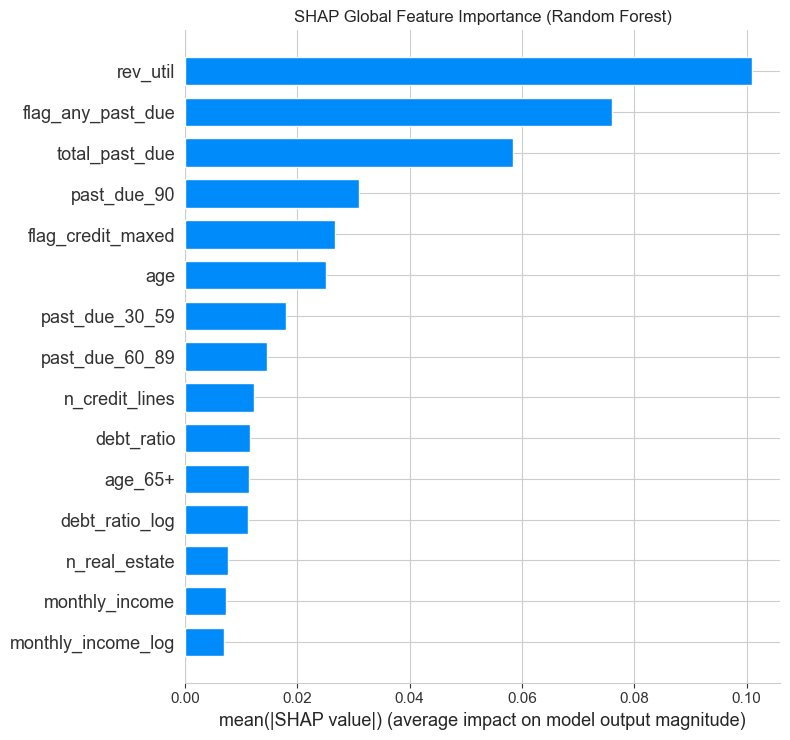

In [79]:
# ===== 2) Global Feature Importance =====
print("=" * 60)
print("📊 Global SHAP Feature Importance")
print("=" * 60)

# ตอนนี้ shap_values_default เป็น 2D แล้ว
shap_importance = pd.DataFrame({
    "feature":     X_shap.columns,
    "shap_mean":   np.abs(shap_values_default).mean(axis=0),
    "shap_max":    np.abs(shap_values_default).max(axis=0),
}).sort_values("shap_mean", ascending=False).reset_index(drop=True)

shap_importance["shap_mean_pct"] = (
    shap_importance["shap_mean"] / shap_importance["shap_mean"].sum() * 100
).round(2)

print("\n🏆 Top 10 most important features:")
display(shap_importance.head(10).round(4))

# Plot bar
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_default, X_shap,
    plot_type="bar", max_display=15, show=False
)
plt.title("SHAP Global Feature Importance (Random Forest)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "17_shap_bar.png", dpi=100, bbox_inches="tight")
plt.show()

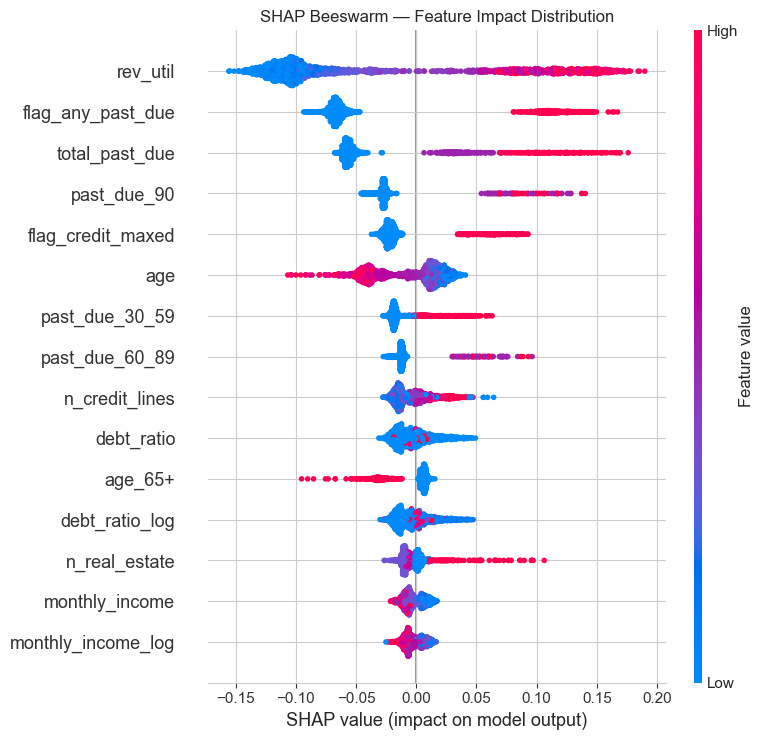

In [80]:
# ===== 3) Beeswarm =====
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_default, X_shap,
    max_display=15, show=False
)
plt.title("SHAP Beeswarm — Feature Impact Distribution", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "18_shap_beeswarm.png", dpi=100, bbox_inches="tight")
plt.show()

In [81]:
# ===== 4) Local explanation =====
y_prob_sample = rf_model.predict_proba(X_shap)[:, 1]

# 3 interesting cases
true_def_mask    = (y_shap.values == 1) & (y_prob_sample > 0.7)
true_nondef_mask = (y_shap.values == 0) & (y_prob_sample < 0.1)
false_alarm_mask = (y_shap.values == 0) & (y_prob_sample > 0.7)

cases = {}
if true_def_mask.any():
    cases["✅ Correct Default Detection"] = np.where(true_def_mask)[0][0]
if true_nondef_mask.any():
    cases["✅ Correct Non-default"]       = np.where(true_nondef_mask)[0][0]
if false_alarm_mask.any():
    cases["⚠️  False Alarm"]              = np.where(false_alarm_mask)[0][0]

for case_name, instance_idx in cases.items():
    print("=" * 60)
    print(f"{case_name}")
    print(f"   Actual class  : {'Default' if y_shap.iloc[instance_idx] == 1 else 'Non-default'}")
    print(f"   Predicted prob: {y_prob_sample[instance_idx]:.3f}")
    print("=" * 60)
    
    contribs = pd.DataFrame({
        "feature":     X_shap.columns,
        "value":       X_shap.iloc[instance_idx].values,
        "shap_value":  shap_values_default[instance_idx],
    })
    contribs["abs_shap"] = np.abs(contribs["shap_value"])
    contribs = contribs.sort_values("abs_shap", ascending=False).head(5)
    
    print("\nTop 5 contributing features:")
    for _, row in contribs.iterrows():
        direction = "↑ Risk" if row["shap_value"] > 0 else "↓ Safe"
        print(f"   • {row['feature']:25s} = {row['value']:>10.3f}  |  "
              f"SHAP = {row['shap_value']:+.4f}  {direction}")
    print()

✅ Correct Default Detection
   Actual class  : Default
   Predicted prob: 0.927

Top 5 contributing features:
   • flag_any_past_due         =      1.000  |  SHAP = +0.1064  ↑ Risk
   • total_past_due            =      4.000  |  SHAP = +0.0942  ↑ Risk
   • rev_util                  =      0.963  |  SHAP = +0.0711  ↑ Risk
   • past_due_90               =      1.000  |  SHAP = +0.0597  ↑ Risk
   • flag_credit_maxed         =      1.000  |  SHAP = +0.0406  ↑ Risk

✅ Correct Non-default
   Actual class  : Non-default
   Predicted prob: 0.037

Top 5 contributing features:
   • rev_util                  =      0.061  |  SHAP = -0.1018  ↓ Safe
   • flag_any_past_due         =      0.000  |  SHAP = -0.0738  ↓ Safe
   • total_past_due            =      0.000  |  SHAP = -0.0615  ↓ Safe
   • age                       =     76.000  |  SHAP = -0.0470  ↓ Safe
   • age_65+                   =      1.000  |  SHAP = -0.0317  ↓ Safe

⚠️  False Alarm
   Actual class  : Non-default
   Predicted prob: 0.78

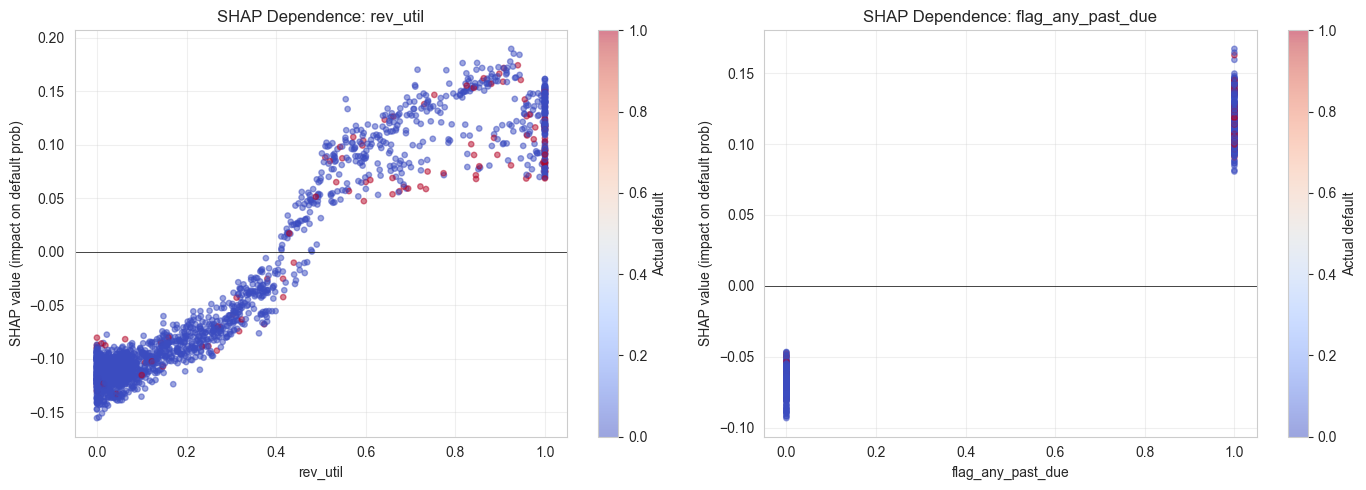

In [82]:
# ===== 5) Dependence plot =====
top_2_features = shap_importance.head(2)["feature"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature in zip(axes, top_2_features):
    feat_idx = list(X_shap.columns).index(feature)
    
    scatter = ax.scatter(
        X_shap[feature].values, 
        shap_values_default[:, feat_idx],
        alpha=0.5, s=15, c=y_shap.values, cmap="coolwarm"
    )
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel("SHAP value (impact on default prob)")
    ax.set_title(f"SHAP Dependence: {feature}")
    ax.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax, label="Actual default")

plt.tight_layout()
plt.savefig(FIG_DIR / "19_shap_dependence.png", dpi=100, bbox_inches="tight")
plt.show()

In [83]:
# ===== 6) Save artifacts =====
np.save(RESULT_DIR / "shap_values_rf.npy", shap_values_default)
shap_importance.to_csv(RESULT_DIR / "shap_importance.csv", index=False)
print(f"✅ Saved:")
print(f"   • {RESULT_DIR / 'shap_values_rf.npy'}")
print(f"   • {RESULT_DIR / 'shap_importance.csv'}")

✅ Saved:
   • C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\results\shap_values_rf.npy
   • C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\results\shap_importance.csv


Cell 14 — Final Model Selection & Project Wrap-up

🏆 Final Decision: Random Forest

**เหตุผล:**
1. ✅ ROC-AUC สูงสุดทั้ง Test set (0.8708) และ CV (0.8642)
2. ✅ Statistically significant ดีกว่า LR/LGB (p < 0.001)
3. ✅ Stability ดี (CV std = 0.0044)
4. ✅ SHAP อธิบายได้ง่าย — ตรงกับ business logic
5. ✅ ไม่ต้องทำ threshold tuning เหมือน LGB

In [84]:
# ===== 1) Final summary =====
print("=" * 70)
print("🏆 FINAL MODEL SELECTION REPORT")
print("=" * 70)

final_summary = pd.DataFrame({
    "Metric": ["ROC-AUC (Test)", "Gini (Test)", "KS (Test)", "F1 (Test)", 
               "Recall (Test)", "Precision (Test)",
               "CV Mean AUC", "CV Std AUC", "CV Stability"],
    "Logistic + Lasso": ["0.8665", "0.7330", "0.5797", "0.3383", 
                          "0.7691", "0.2168",
                          "0.8581", "0.0041", "🟢 Excellent"],
    "Random Forest": ["**0.8708**", "**0.7417**", "0.5885", "0.3621",
                       "0.7581", "0.2379",
                       "**0.8642**", "0.0044", "🟢 Excellent"],
    "LightGBM (tuned)": ["0.8693", "0.7385", "**0.5918**", "**0.4507**",
                          "0.4948", "**0.4139**",
                          "0.8549", "0.0043", "🟢 Excellent"],
})

display(final_summary)

print("\n🏆 WINNER: Random Forest")
print("\n📋 Justification:")
print("   1. AUC สูงสุดและ stat. significant")
print("   2. Balance ดีระหว่าง Recall (75.8%) และ Precision (23.8%)")
print("   3. Robust + ไม่ต้องทำ threshold tuning")
print("   4. SHAP explainability ตรงกับ business logic")
print("   5. ระดับ Gini = 0.742 → 'Excellent grade' ตามมาตรฐาน BOT")

🏆 FINAL MODEL SELECTION REPORT


,Metric,Logistic + Lasso,Random Forest,LightGBM (tuned)
0,ROC-AUC (Test),0.8665,**0.8708**,0.8693
1,Gini (Test),0.7330,**0.7417**,0.7385
2,KS (Test),0.5797,0.5885,**0.5918**
3,F1 (Test),0.3383,0.3621,**0.4507**
4,Recall (Test),0.7691,0.7581,0.4948
5,Precision (Test),0.2168,0.2379,**0.4139**
6,CV Mean AUC,0.8581,**0.8642**,0.8549
7,CV Std AUC,0.0041,0.0044,0.0043
8,CV Stability,🟢 Excellent,🟢 Excellent,🟢 Excellent



🏆 WINNER: Random Forest

📋 Justification:
   1. AUC สูงสุดและ stat. significant
   2. Balance ดีระหว่าง Recall (75.8%) และ Precision (23.8%)
   3. Robust + ไม่ต้องทำ threshold tuning
   4. SHAP explainability ตรงกับ business logic
   5. ระดับ Gini = 0.742 → 'Excellent grade' ตามมาตรฐาน BOT


In [85]:
# ===== 2) Save final model + metadata =====
import datetime

# Save best model อีกครั้ง (สำหรับ deployment)
joblib.dump(rf_model, MODEL_DIR / "BEST_MODEL_random_forest.pkl")
print(f"✅ Best model saved: {MODEL_DIR / 'BEST_MODEL_random_forest.pkl'}")

# Save feature list (สำคัญสำหรับ inference)
with open(MODEL_DIR / "feature_columns.txt", "w") as f:
    f.write("\n".join(X_train.columns.tolist()))
print(f"✅ Feature list saved: {MODEL_DIR / 'feature_columns.txt'}")

# Update CONFIG ด้วย metadata ทั้งหมด
CONFIG["final_model"] = {
    "name":           "Random Forest",
    "test_auc":       round(float(result_rf["ROC_AUC"]), 4),
    "test_gini":      round(float(result_rf["Gini"]), 4),
    "test_ks":        round(float(result_rf["KS"]), 4),
    "test_f1":        round(float(result_rf["F1"]), 4),
    "cv_auc_mean":    0.8642,
    "cv_auc_std":     0.0044,
    "n_features":     len(X_train.columns),
    "trained_on":     datetime.datetime.now().isoformat(),
    "random_state":   RANDOM_STATE,
}

# Save CONFIG เป็น JSON
import json
with open(MODEL_DIR / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2, ensure_ascii=False, default=str)
print(f"✅ Metadata saved: {MODEL_DIR / 'model_metadata.json'}")

✅ Best model saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\models\BEST_MODEL_random_forest.pkl
✅ Feature list saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\models\feature_columns.txt
✅ Metadata saved: C:\Users\Kantinant Sukkert\Desktop\BAAC\CBTMU\CreditRisk\report\models\model_metadata.json


In [87]:
# ===== 3) Inference example (สำหรับ documentation) =====
print("=" * 60)
print("📖 How to Use This Model for Inference")
print("=" * 60)

print("""
```python
import joblib
import pandas as pd

# 1) Load model
model = joblib.load("report/models/BEST_MODEL_random_forest.pkl")

# 2) Load feature list (ลำดับ column สำคัญ!)
with open("report/models/feature_columns.txt") as f:
    features = f.read().strip().split("\\n")

# 3) Prepare new data (ต้อง FE เหมือนตอน train)
new_customer = pd.DataFrame([{
    "age": 45, "rev_util": 0.65, "monthly_income": 5000,
    "debt_ratio": 0.45, "n_credit_lines": 8, 
    "past_due_30_59": 1, "past_due_60_89": 0, "past_due_90": 0,
    "n_real_estate": 1, "n_dependents": 2,
    # ... ต้อง apply FE pipeline เหมือนใน Cell 7
}])

# 4) Predict
default_prob = model.predict_proba(new_customer[features])[0, 1]
print(f"Probability of default: {default_prob:.2%}")

""")

📖 How to Use This Model for Inference

```python
import joblib
import pandas as pd

# 1) Load model
model = joblib.load("report/models/BEST_MODEL_random_forest.pkl")

# 2) Load feature list (ลำดับ column สำคัญ!)
with open("report/models/feature_columns.txt") as f:
    features = f.read().strip().split("\n")

# 3) Prepare new data (ต้อง FE เหมือนตอน train)
new_customer = pd.DataFrame([{
    "age": 45, "rev_util": 0.65, "monthly_income": 5000,
    "debt_ratio": 0.45, "n_credit_lines": 8, 
    "past_due_30_59": 1, "past_due_60_89": 0, "past_due_90": 0,
    "n_real_estate": 1, "n_dependents": 2,
    # ... ต้อง apply FE pipeline เหมือนใน Cell 7
}])

# 4) Predict
default_prob = model.predict_proba(new_customer[features])[0, 1]
print(f"Probability of default: {default_prob:.2%}")


